# Import Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

from scipy.stats import chi2_contingency, f_oneway, jarque_bera, probplot
import plotly.express as px
pd.set_option('display.max_columns' , None)
pd.set_option('display.max_rows' , None)

https://www.kaggle.com/code/matinmahmoudi/complete-guide-to-descriptive-stats-a-to-z

# Load the Data

In [2]:
# load the data

df1 = pd.read_csv('swiggy.csv')

df1.sample(10)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
30348,0xdc2b,AGRRES16DEL02,31,4.5,0.000000,0.000000,0.130000,0.130000,18-02-2022,18:10:00,18:15:00,conditions Cloudy,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 37
40909,0xc24f,KNPRES09DEL03,35,4.8,26.473698,80.352677,26.563698,80.442677,16-02-2022,19:55:00,20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,2,Yes,Metropolitian,(min) 43
14468,0xad37,COIMBRES11DEL02,32,4.8,11.001753,76.986241,11.051753,77.036241,07-03-2022,23:25:00,23:40:00,conditions Stormy,Low,2,Drinks,electric_scooter,1,No,NaN,(min) 21
11968,0x7005,INDORES11DEL03,21,4.6,22.751234,75.889490,22.781234,75.919490,15-03-2022,23:50:00,00:00:00,conditions Sunny,Low,0,Drinks,motorcycle,1,No,Urban,(min) 13
10625,0x4e9e,BANGRES13DEL02,22,4.6,12.935662,77.614130,13.065662,77.744130,23-03-2022,22:40:00,22:45:00,conditions Cloudy,Low,1,Drinks,scooter,1,No,Metropolitian,(min) 24
14043,0x98ed,INDORES05DEL02,35,4.1,22.727021,75.884167,22.857021,76.014167,20-03-2022,19:00:00,19:05:00,conditions Stormy,Medium,2,Snack,motorcycle,1,No,Metropolitian,(min) 33
3824,0xbb9b,COIMBRES03DEL01,26,4.8,11.025083,77.015393,11.065083,77.055393,19-03-2022,15:20:00,15:35:00,conditions Windy,Medium,0,Snack,motorcycle,1,No,Urban,(min) 24
35107,0x4a4b,COIMBRES01DEL03,27,4.6,11.016298,76.972076,11.046298,77.002076,17-03-2022,18:55:00,19:00:00,conditions Cloudy,Medium,0,Drinks,motorcycle,1,No,Metropolitian,(min) 21
29377,0x8bf7,COIMBRES05DEL02,32,4.7,11.022169,76.999594,11.072169,77.049594,03-03-2022,20:50:00,20:55:00,conditions Fog,Jam,1,Buffet,scooter,1,No,Metropolitian,(min) 29
43936,0x7f31,PUNERES15DEL01,34,4.9,18.636215,73.751081,18.646215,73.761081,07-03-2022,08:55:00,09:10:00,conditions Cloudy,Low,2,Meal,scooter,1,No,Metropolitian,(min) 17


# Data Cleaning

In [3]:
df1.shape

(45593, 20)

In [4]:
# load the cleaned data

df_final = pd.read_csv('swiggy_cleaned_data.csv')


In [5]:
df_final.head(10)

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time,order_time_of_day,distance
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,24.0,INDO,19,3,Saturday,True,15.0,morning,3.025149
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33.0,BANG,25,3,Friday,False,5.0,night,20.183530
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26.0,BANG,19,3,Saturday,True,15.0,morning,1.552758
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21.0,COIMB,5,4,Tuesday,False,10.0,evening,7.790401
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30.0,CHEN,26,3,Saturday,True,15.0,afternoon,6.210138
5,22.0,4.8,cloudy,jam,0,buffet,motorcycle,1.0,no,urban,26.0,HYD,11,3,Friday,False,10.0,night,4.610365
6,33.0,4.7,fog,jam,1,meal,scooter,1.0,no,metropolitian,40.0,RANCHI,4,3,Friday,False,15.0,night,16.600361
7,35.0,4.6,cloudy,medium,2,meal,motorcycle,1.0,no,metropolitian,32.0,MYS,14,3,Monday,False,5.0,evening,20.205253
8,22.0,4.8,stormy,jam,0,buffet,motorcycle,1.0,no,metropolitian,34.0,HYD,20,3,Sunday,True,10.0,night,19.975520
9,36.0,4.2,fog,jam,2,snack,motorcycle,3.0,no,metropolitian,46.0,DEH,12,2,Saturday,True,15.0,night,10.280582


In [6]:
df_final.columns

Index(['age', 'ratings', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time', 'order_time_of_day',
       'distance'],
      dtype='object')

In [7]:
df_final.head()

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time,order_time_of_day,distance
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,24.0,INDO,19,3,Saturday,True,15.0,morning,3.025149
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33.0,BANG,25,3,Friday,False,5.0,night,20.183530
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26.0,BANG,19,3,Saturday,True,15.0,morning,1.552758
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21.0,COIMB,5,4,Tuesday,False,10.0,evening,7.790401
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30.0,CHEN,26,3,Saturday,True,15.0,afternoon,6.210138


In [8]:
df_final.shape

(45073, 19)

# Preliminary Analysis

In [9]:
# check for missing values in the data

df_final.isnull().sum()

age                    1425
ratings                1479
weather                  96
traffic                  81
vehicle_condition         0
type_of_order             0
type_of_vehicle           0
multiple_deliveries     984
festival                225
city_type              1180
time_taken                0
city_name                 0
order_day                 0
order_month               0
order_day_of_week         0
is_weekend                0
pickup_time            1211
order_time_of_day      1211
distance               3601
dtype: int64

In [10]:
# number of rows in the data that have missing values

missing_rows = (df_final.isnull().any(axis=1).sum())

print(f'There are {missing_rows} rows with missing values in the data.')

print(f"It accounts for {(missing_rows/df_final.shape[0])*100:.2f}% of the data")

There are 7009 rows with missing values in the data.
It accounts for 15.55% of the data


In [11]:
# check for duplicate rows in the data

df_final.duplicated().sum()

np.int64(0)

**There are no duplicate rows in the data and none were created by our data cleaning step**

In [12]:
# data types of features

df_final.dtypes

age                    float64
ratings                float64
weather                 object
traffic                 object
vehicle_condition        int64
type_of_order           object
type_of_vehicle         object
multiple_deliveries    float64
festival                object
city_type               object
time_taken             float64
city_name               object
order_day                int64
order_month              int64
order_day_of_week       object
is_weekend                bool
pickup_time            float64
order_time_of_day       object
distance               float64
dtype: object

In [13]:
num_cols = [col for col in df_final.columns.to_list() if df_final[col].dtype != 'object']
cat_cols = [col for col in df_final.columns.to_list() if df_final[col].dtype == 'object']

In [14]:
num_cols

['age',
 'ratings',
 'vehicle_condition',
 'multiple_deliveries',
 'time_taken',
 'order_day',
 'order_month',
 'is_weekend',
 'pickup_time',
 'distance']

In [15]:
cat_cols

['weather',
 'traffic',
 'type_of_order',
 'type_of_vehicle',
 'festival',
 'city_type',
 'city_name',
 'order_day_of_week',
 'order_time_of_day']

In [16]:
# statistical summary of numerical columns

df_final[num_cols].describe()

,age,ratings,vehicle_condition,multiple_deliveries,time_taken,order_day,order_month,pickup_time,distance
count,43648.000000,43594.000000,45073.000000,44089.000000,45073.000000,45073.000000,45073.000000,43862.000000,41472.000000
mean,29.555008,4.635287,1.000555,0.744449,26.292326,13.814501,2.980432,9.989399,9.718280
std,5.761482,0.313827,0.816428,0.572254,9.383887,8.709403,0.546245,4.087516,5.601163
min,20.000000,2.500000,0.000000,0.000000,10.000000,1.000000,2.000000,5.000000,1.465067
25%,25.000000,4.500000,0.000000,0.000000,19.000000,6.000000,3.000000,5.000000,4.657655
50%,30.000000,4.700000,1.000000,1.000000,26.000000,13.000000,3.000000,10.000000,9.193014
75%,35.000000,4.900000,2.000000,1.000000,32.000000,20.000000,3.000000,15.000000,13.680920
max,39.000000,5.000000,2.000000,3.000000,54.000000,31.000000,4.000000,15.000000,20.969489


In [17]:
df_final['pickup_time'].value_counts()

pickup_time
5.0     14703
15.0    14610
10.0    14549
Name: count, dtype: int64

In [18]:
df_final[cat_cols].describe()

,weather,traffic,type_of_order,type_of_vehicle,festival,city_type,city_name,order_day_of_week,order_time_of_day
count,44977,44992,45073,45073,44848,43893,45073,45073,43862
unique,6,4,4,3,2,3,22,7,5
top,fog,low,snack,motorcycle,no,metropolitian,JAP,Wednesday,night
freq,7654,15477,11392,26345,43967,33693,3412,7013,18396


## Missing Value Analysis

In [19]:
import missingno as msno

### Matrix Plot


<Axes: >

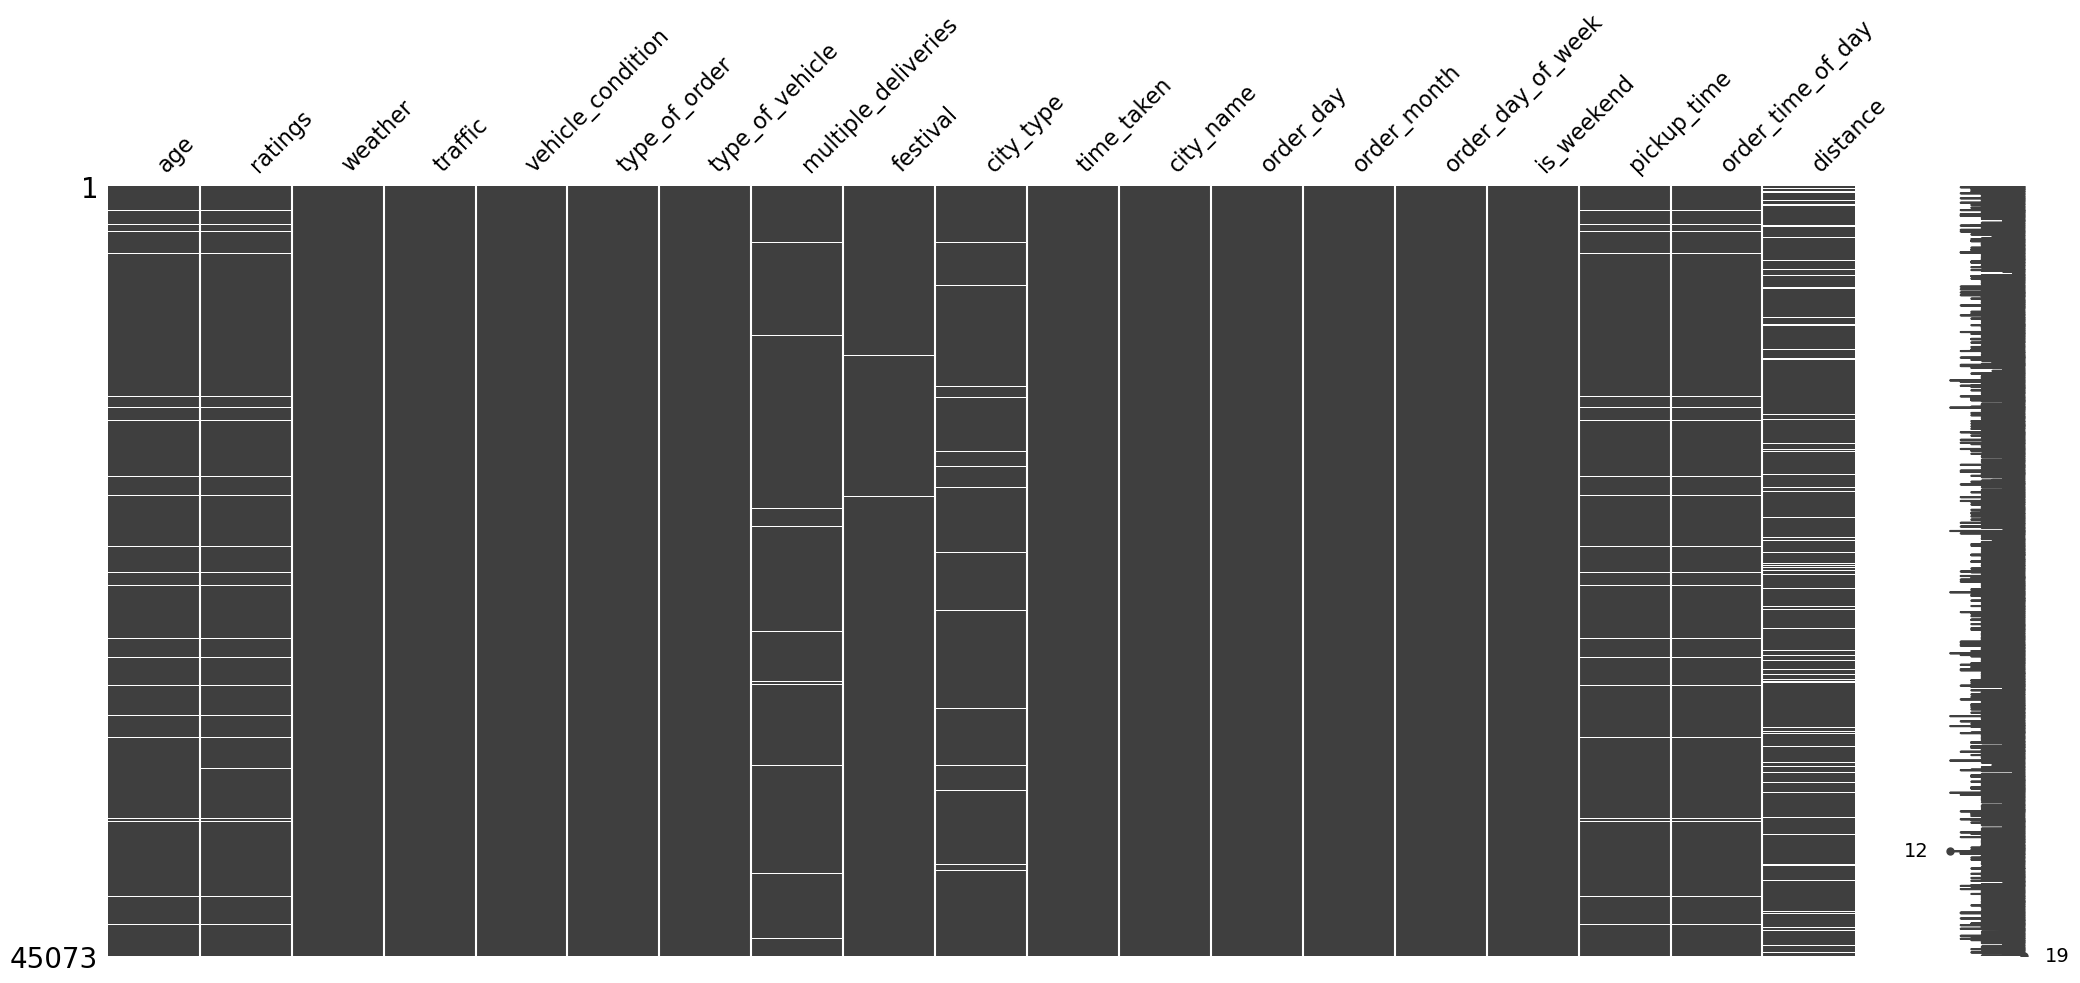

In [20]:
msno.matrix(df_final)

### Corr

<Axes: >

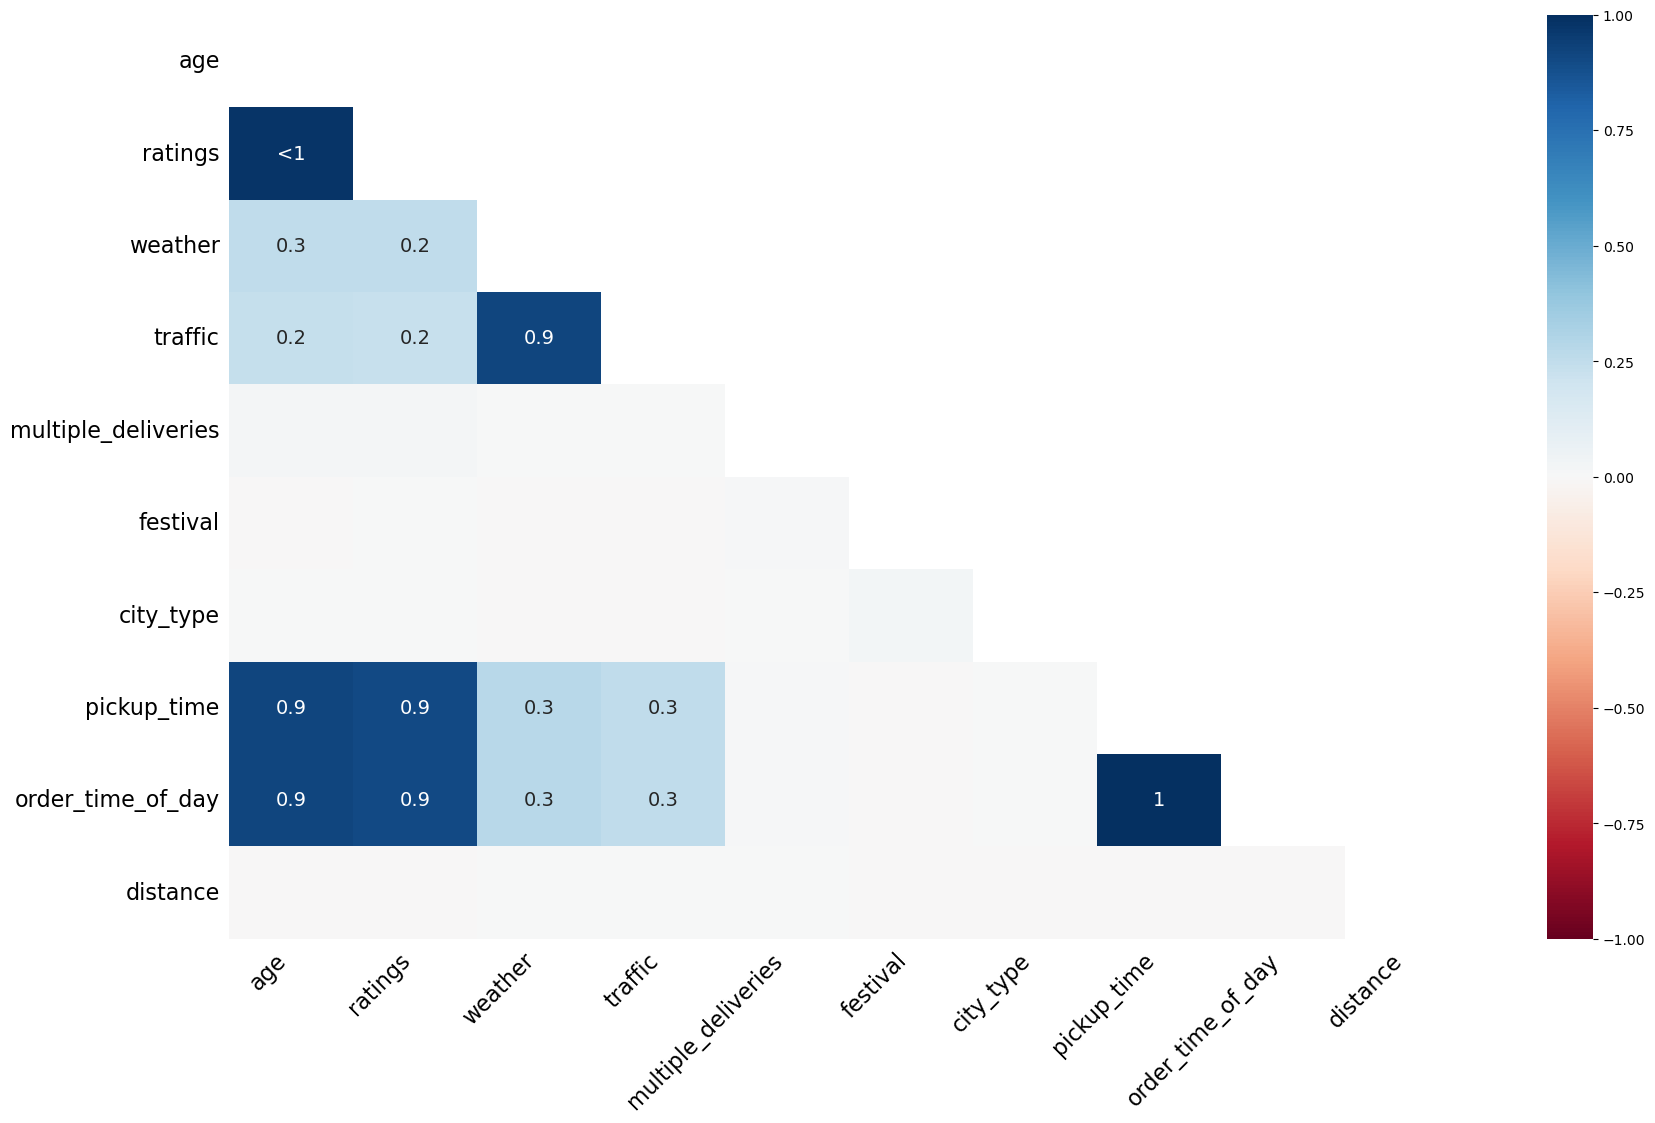

In [21]:
msno.heatmap(df_final)

### Dendrogram

<Axes: >

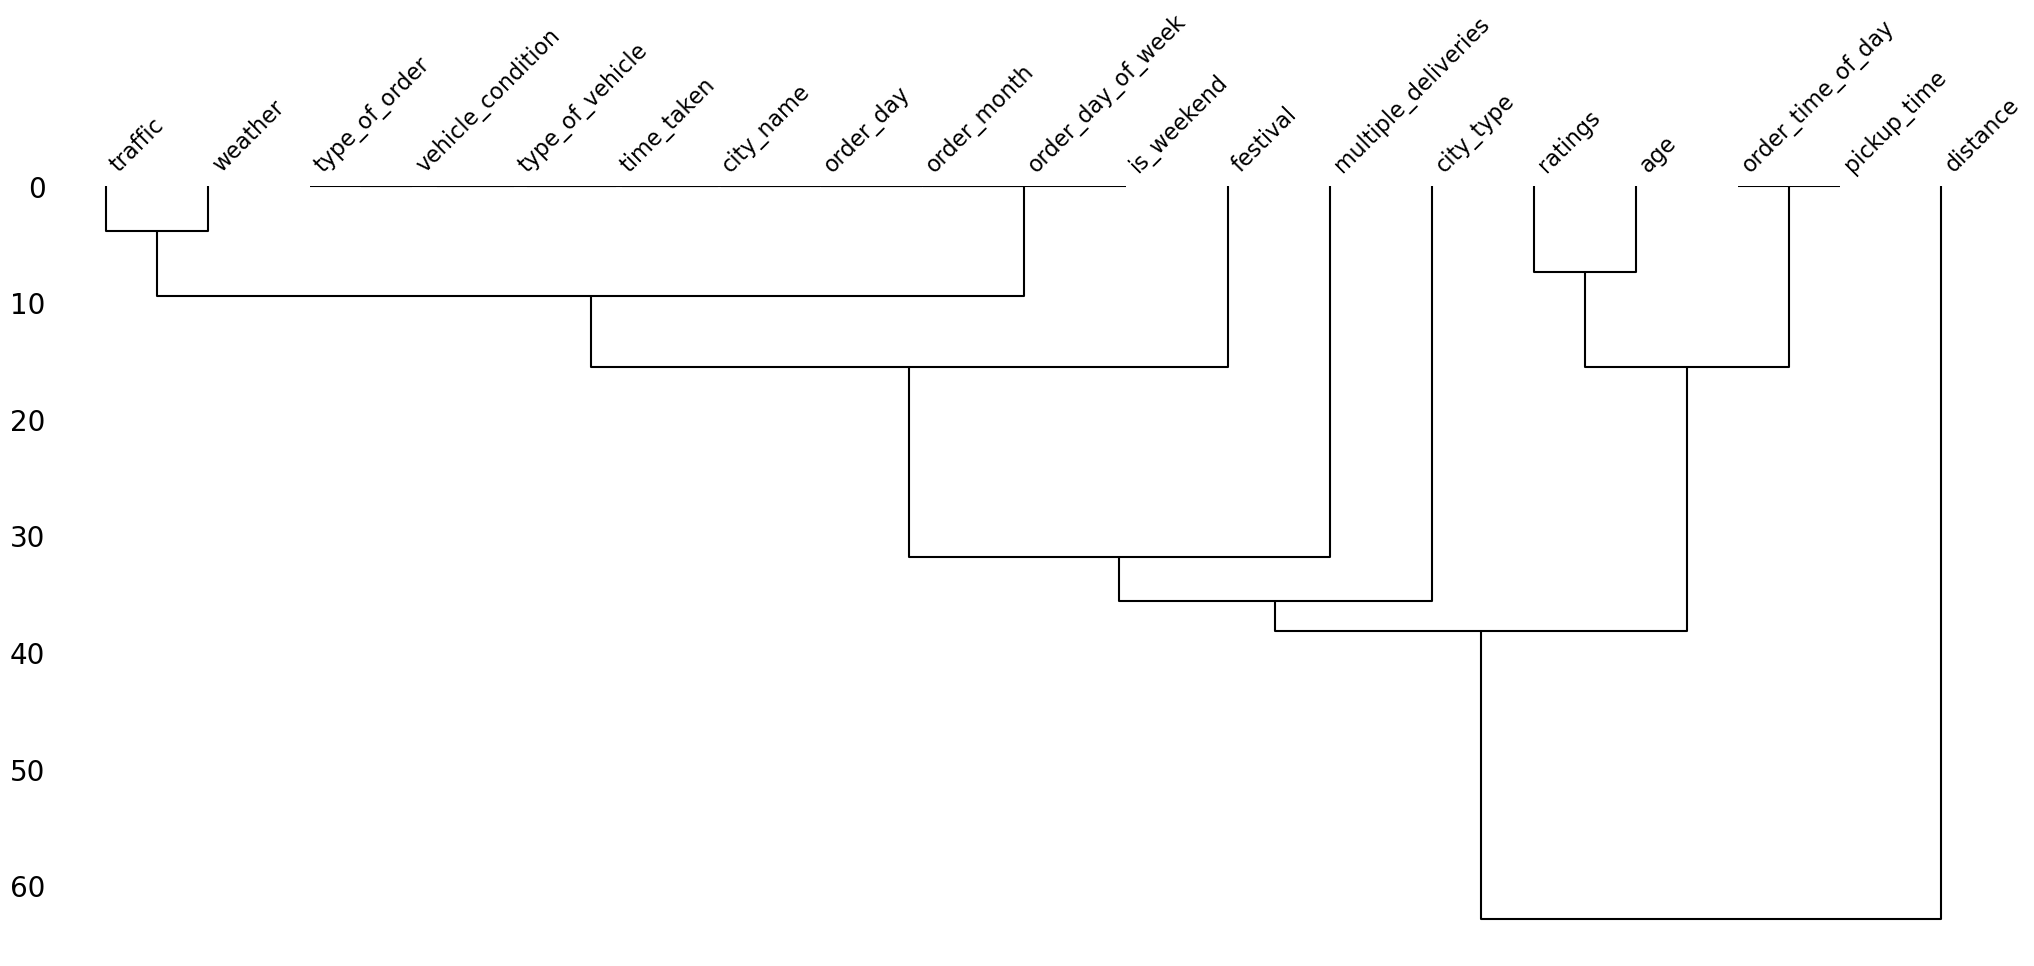

In [22]:
msno.dendrogram(df_final)

# Functions to perform analysis

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def numerical_analysis(df, num_col, cat_col=None, bins="auto"):


    # Create a figure with subplots using GridSpec
    fig = plt.figure(figsize=(15, 10))
    grid = GridSpec(nrows=2, ncols=2, figure=fig)

    ax1 = fig.add_subplot(grid[0, 0])  # KDE plot
    ax2 = fig.add_subplot(grid[0, 1])  # Box plot
    ax3 = fig.add_subplot(grid[1, :])  # Histogram

    # KDE Plot (smoothed distribution)
    sns.kdeplot(data=df, x=num_col, hue=cat_col, ax=ax1)
    ax1.set_title("KDE Plot")

    # Box Plot (outliers + distribution)
    sns.boxplot(data=df, x=num_col,hue=cat_col, ax=ax2)
    ax2.set_title("Box Plot")

    # Histogram (with bins + KDE)
    sns.histplot(data=df, x=num_col, hue=cat_col, bins=bins, kde=True, ax=ax3)
    ax3.set_title("Histogram")

    plt.tight_layout()
    plt.show()



def numerical_categorical_analysis(dataframe, cat_column, num_column):
    # Create a 2x2 subplot grid
    fig, axes = plt.subplots(2, 2, figsize=(15, 8))

    # Bar Plot - shows average of num_column per category
    sns.barplot(data=dataframe, x=cat_column, y=num_column, ax=axes[0, 0])
    axes[0, 0].set_title("Bar Plot (Mean per Category)")

    # Box Plot - shows distribution + outliers
    sns.boxplot(data=dataframe, x=cat_column, y=num_column, ax=axes[0, 1])
    axes[0, 1].set_title("Box Plot")

    # Violin Plot - combines KDE & boxplot
    sns.violinplot(data=dataframe, x=cat_column, y=num_column, ax=axes[1, 0])
    axes[1, 0].set_title("Violin Plot")

    # Strip Plot - raw individual data points
    sns.stripplot(data=dataframe, x=cat_column, y=num_column, ax=axes[1, 1])
    axes[1, 1].set_title("Strip Plot")

    # Layout adjustments
    plt.tight_layout()
    plt.show()



def categorical_analysis(dataframe, column_name):
    # Create a summary DataFrame with count and percentage
    value_counts = dataframe[column_name].value_counts()
    percentage = dataframe[column_name].value_counts(normalize=True) * 100

    summary_df = pd.DataFrame({
        "Count": value_counts,
        "Percentage": percentage.round(2).astype(str).add('%')
    })

    display(summary_df)

    print("*" * 50)

    # Unique values and their count
    unique_categories = dataframe[column_name].dropna().unique().tolist()
    number_of_categories = dataframe[column_name].nunique(dropna=True)

    print(f" Unique categories in '{column_name}': {unique_categories}")
    print(f" Total number of categories: {number_of_categories}")
    print("*" * 50)

    # Plot count plot
    plt.figure(figsize=(10, 5))
    sns.countplot(data=dataframe, x=column_name, order=value_counts.index)
    plt.title(f"Count Plot of {column_name}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



def multivariate_analysis(dataframe, num_column, cat_column_1, cat_column_2):
    fig, axs = plt.subplots(2, 2, figsize=(16, 10))

    # 1. Bar plot
    sns.barplot(data=dataframe, x=cat_column_1, y=num_column,
                hue=cat_column_2, ax=axs[0, 0])
    axs[0, 0].set_title(f'Barplot of {num_column} by {cat_column_1} and {cat_column_2}')

    # 2. Box plot
    sns.boxplot(data=dataframe, x=cat_column_1, y=num_column,
                hue=cat_column_2, ax=axs[0, 1])
    axs[0, 1].set_title(f'Boxplot of {num_column} by {cat_column_1} and {cat_column_2}')

    # 3. Violin plot
    sns.violinplot(data=dataframe, x=cat_column_1, y=num_column,
                   hue=cat_column_2, split=True, ax=axs[1, 0])
    axs[1, 0].set_title(f'Violin plot of {num_column} by {cat_column_1} and {cat_column_2}')

    # 4. Strip plot
    sns.stripplot(data=dataframe, x=cat_column_1, y=num_column,
                  hue=cat_column_2, dodge=True, alpha=0.5, ax=axs[1, 1])
    axs[1, 1].set_title(f'Strip plot of {num_column} by {cat_column_1} and {cat_column_2}')

    # Adjust layout and show
    plt.tight_layout()
    plt.show()


def chi_2_test(dataframe, col1, col2, alpha= 0.05):
    data = (
        dataframe.loc[:, [col1, col2]]
        .dropna()
    )
    # create contingency table
    contingency_table = pd.crosstab(data[col1], data[col2])
    # perform chi-squared test
    _, p_val, _, _ = chi2_contingency(contingency_table)
    print(p_val)
    if p_val <= alpha:
        print(f"Reject the null hypothesis. There is a significant association between {col1} and {col2}.")
    else:
        print(f"Fail to reject the null hypothesis. There is no significant association between {col1} and {col2}.")

def anova_test(dataframe, num_col, cat_col, alpha=0.05):
    data = (
        dataframe.loc[:, [num_col, cat_col]]
        .dropna()
    )
    cat_group = data.groupby(cat_col)
    groups = [group[num_col].values for _, group in cat_group]
    f_stat, p_val = f_oneway(*groups)
    print(p_val)
    if p_val <= alpha:
        print(f"Reject the null hypothesis. There is a significant relationship between {num_col} and {cat_col}.")
    else:
        print(f"Fail to reject the null hypothesis. There is no significant relationship between {num_col} and {cat_col}.")

def test_for_normality(dataframe, column_name, alpha=0.05):
    data = dataframe[column_name]
    print("Jarque Bera Test for Normality")
    _, p_val = jarque_bera(data)
    print(p_val)
    if p_val <= alpha:
        print(f"Reject the null hypothesis. The data is not normally distributed.")
    else:
        print(f"Fail to reject the null hypothesis. The data is normally distributed.",end="\n\n")


# Column Wise Analysis

In [24]:
df_final.columns

Index(['age', 'ratings', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time', 'order_time_of_day',
       'distance'],
      dtype='object')

## Time Taken (Target)

In [25]:
# data type of column

df_final['time_taken'].dtype

dtype('float64')

In [26]:
df_final['time_taken'].isnull().sum()

np.int64(0)

In [27]:
df_final['time_taken'].describe()

count    45073.000000
mean        26.292326
std          9.383887
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: time_taken, dtype: float64

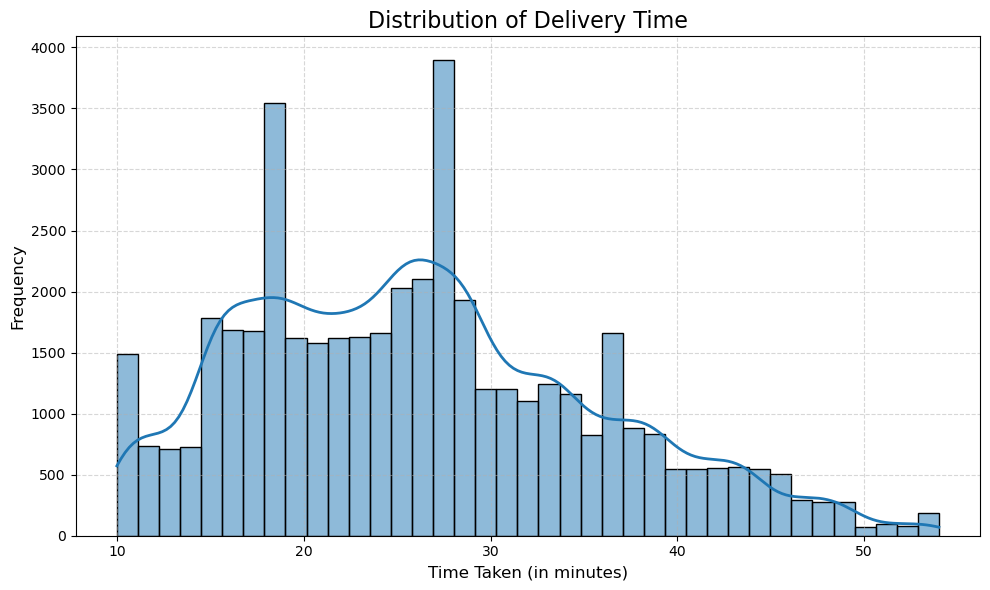

In [28]:
plt.figure(figsize=(10, 6))
sns.histplot(
    df_final['time_taken'],
    kde=True,
    bins=39,
    #color='skyblue',
    edgecolor='black',
    line_kws={'color': 'red', 'linewidth': 2}  # use line_kws instead of kde_kws
)
plt.title('Distribution of Delivery Time', fontsize=16)
plt.xlabel('Time Taken (in minutes)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



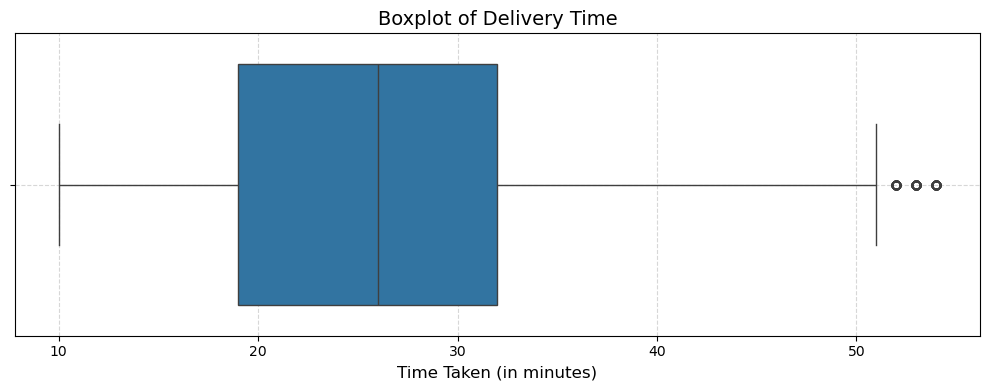

In [29]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_final['time_taken'])
plt.title("Boxplot of Delivery Time", fontsize=14)
plt.xlabel("Time Taken (in minutes)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [30]:
# Skewness and Kurtosis
skewness = df_final['time_taken'].skew()
kurtosis = df_final['time_taken'].kurt()

print(skewness,kurtosis)

0.48566367481160283 -0.3118775412199253


In [31]:
import numpy as np
from sklearn.preprocessing import PowerTransformer

# Log Transformation
df_final['time_taken_log'] = np.log1p(df_final['time_taken'])

# Yeo-Johnson Transformation
pt = PowerTransformer(method='yeo-johnson')
df_final['time_taken_yeojohnson'] = pt.fit_transform(df_final[['time_taken']])


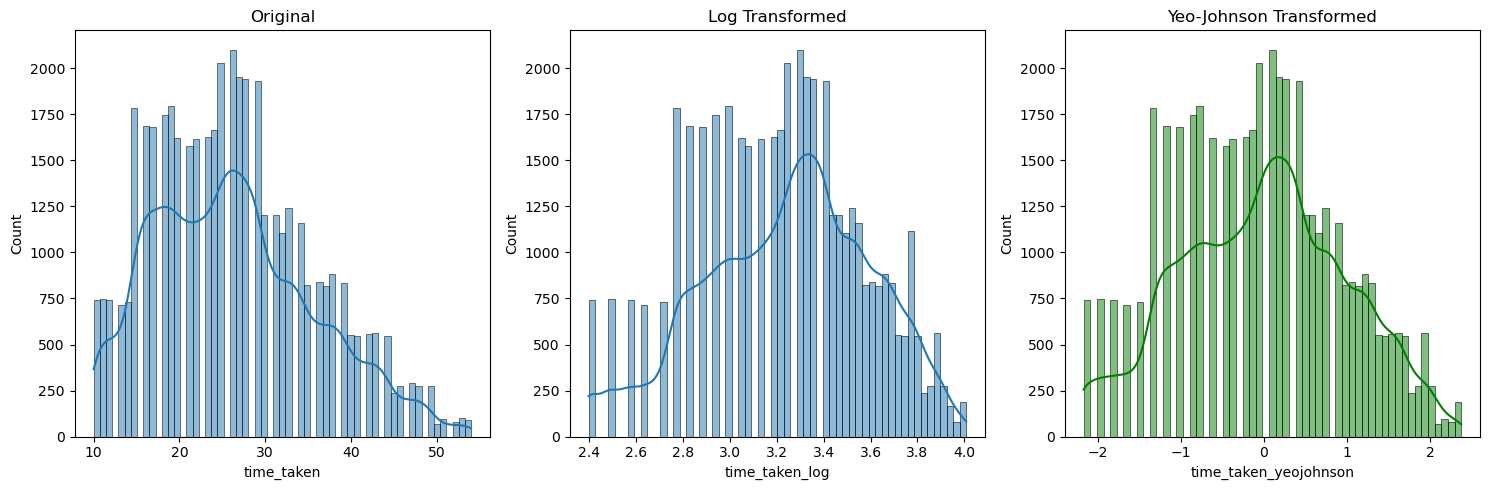

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

# Original
plt.subplot(1, 3, 1)
sns.histplot(df_final['time_taken'], kde=True)
plt.title("Original")

# Log Transformed
plt.subplot(1, 3, 2)
sns.histplot(df_final['time_taken_log'], kde=True)
plt.title("Log Transformed")

# Yeo-Johnson Transformed
plt.subplot(1, 3, 3)
sns.histplot(df_final['time_taken_yeojohnson'], kde=True, color='green')
plt.title("Yeo-Johnson Transformed")

plt.tight_layout()
plt.show()



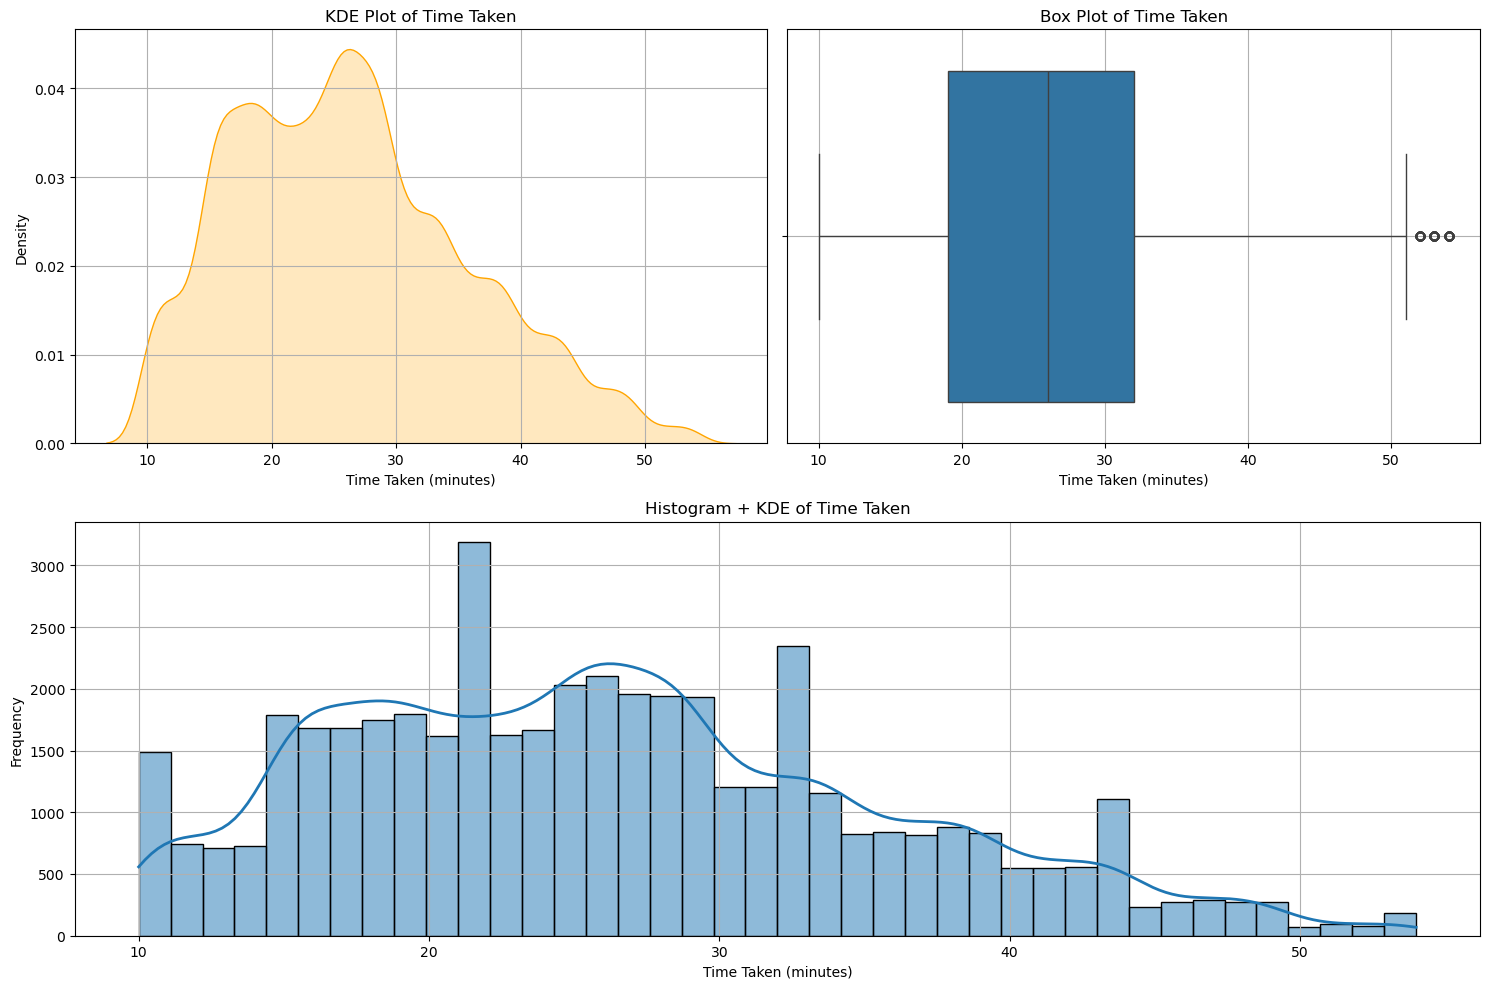

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Create the figure
fig = plt.figure(figsize=(15, 10))
grid = GridSpec(nrows=2, ncols=2, figure=fig)

# KDE plot
ax1 = fig.add_subplot(grid[0, 0])
sns.kdeplot(data=df_final, x='time_taken', fill=True, color='orange', ax=ax1)
ax1.set_title('KDE Plot of Time Taken')
ax1.set_xlabel('Time Taken (minutes)')
ax1.grid(True)

# Box plot
ax2 = fig.add_subplot(grid[0, 1])
sns.boxplot(x=df_final['time_taken'], ax=ax2)
ax2.set_title('Box Plot of Time Taken')
ax2.set_xlabel('Time Taken (minutes)')
ax2.grid(True)

# Histogram with KDE
ax3 = fig.add_subplot(grid[1, :])
sns.histplot(
    df_final['time_taken'],
    kde=True,
    bins=40,
    #color='skyblue',
    edgecolor='black',
    line_kws={'color': 'red', 'linewidth': 2},  # Corrected here
    ax=ax3
)
ax3.set_title('Histogram + KDE of Time Taken')
ax3.set_xlabel('Time Taken (minutes)')
ax3.set_ylabel('Frequency')
ax3.grid(True)

plt.tight_layout()
plt.show()



**Observations**:

1. The target column is not fully continuous in nature.
2. The target column shows dual modality with two peaks- One peak around the 17-18 mark and other around 26-27 mark.
4. The target column has some extreme points which can be thought of as outliers but they are just extreme and rare, not outliers. 50 min time is possible for delivery in certain rare cases.

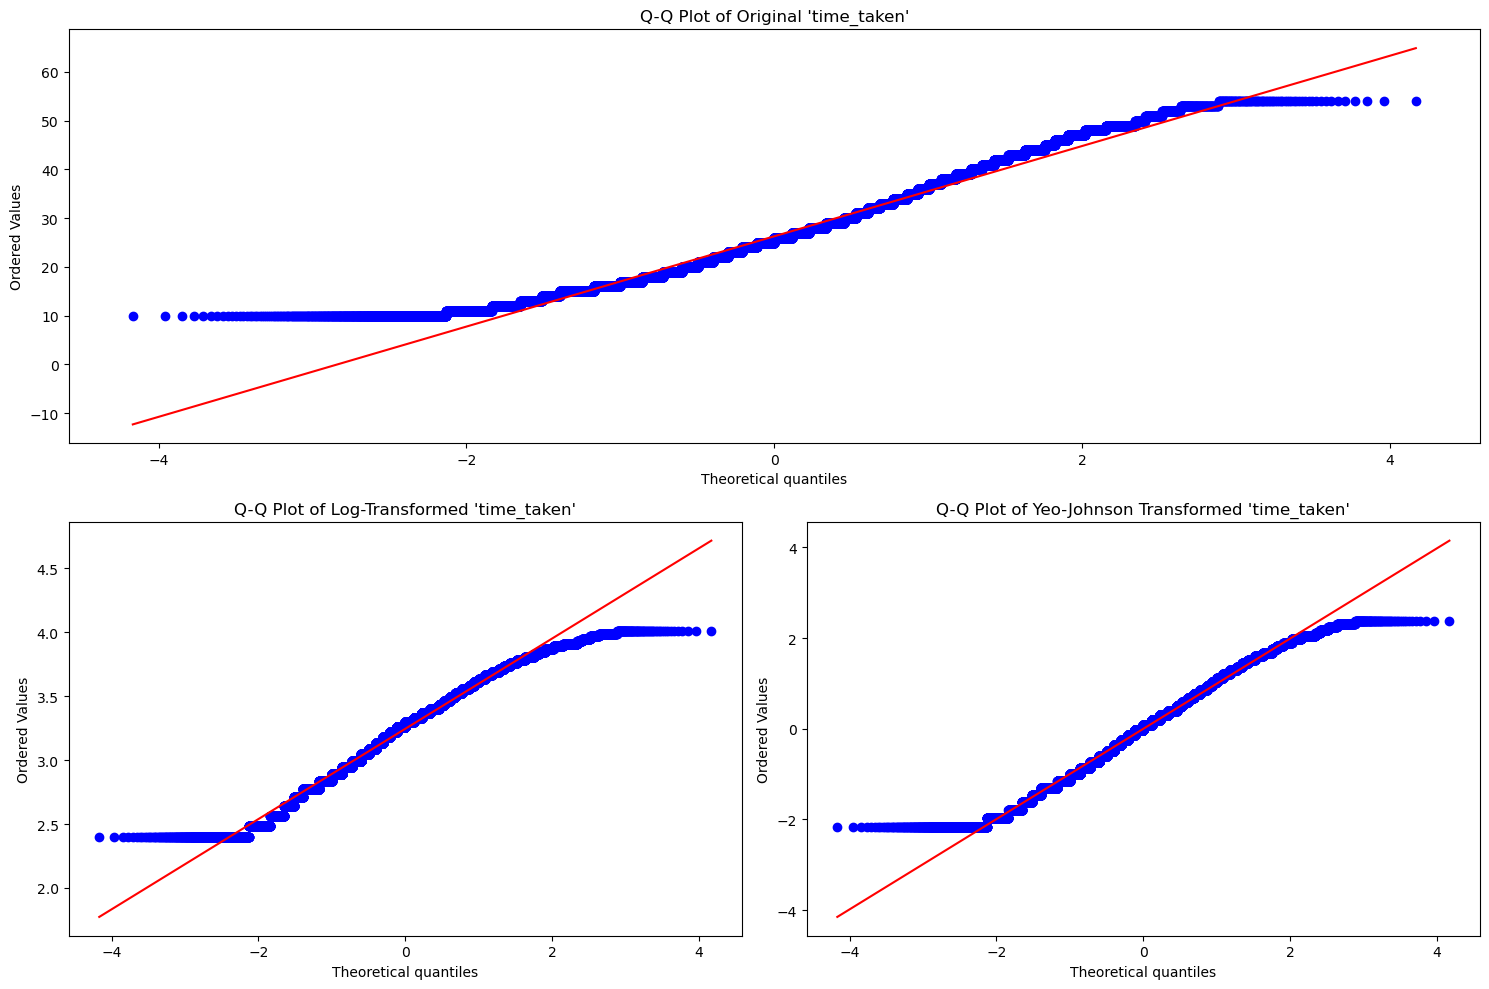

In [34]:
from scipy.stats import probplot
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Create Q-Q plot figure
fig = plt.figure(figsize=(15, 10))
grid = GridSpec(nrows=2, ncols=2, figure=fig)

# Original data
ax1 = fig.add_subplot(grid[0, :])
plt.sca(ax1)
probplot(df_final['time_taken'], dist="norm", plot=plt)
ax1.set_title("Q-Q Plot of Original 'time_taken'")

# Log-transformed data
ax2 = fig.add_subplot(grid[1, 0])
plt.sca(ax2)
probplot(df_final['time_taken_log'], dist="norm", plot=plt)
ax2.set_title("Q-Q Plot of Log-Transformed 'time_taken'")

# Yeo-Johnson transformed data
ax3 = fig.add_subplot(grid[1, 1])
plt.sca(ax3)
probplot(df_final['time_taken_yeojohnson'], dist="norm", plot=plt)
ax3.set_title("Q-Q Plot of Yeo-Johnson Transformed 'time_taken'")

plt.tight_layout()
plt.show()


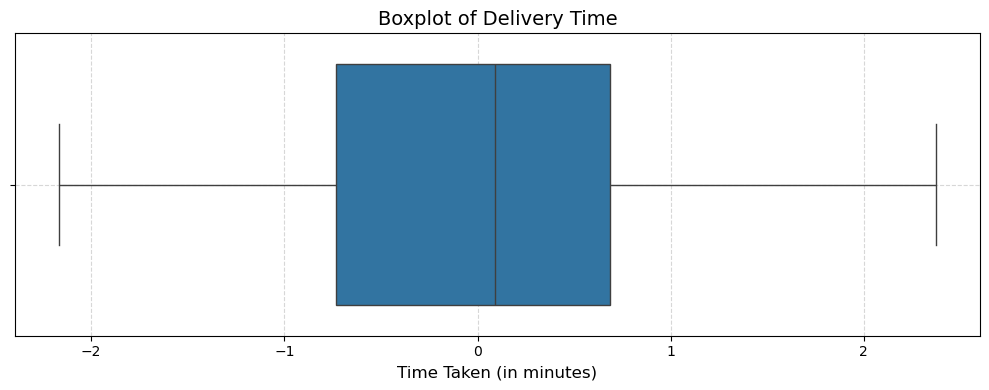

In [35]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_final['time_taken_yeojohnson'])
plt.title("Boxplot of Delivery Time", fontsize=14)
plt.xlabel("Time Taken (in minutes)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [36]:
# check out the rows where data is acting as outlier
#Lower Bound = Q1 - 1.5 * IQR  
#Upper Bound = Q3 + 1.5 * IQR

target_25_per, target_75_per = np.percentile(df_final['time_taken'], [25, 75])
iqr = target_75_per - target_25_per

upper_bound = target_75_per + (1.5 * iqr)

df_final.loc[(df_final['time_taken'] > upper_bound),"traffic"].value_counts()

traffic
jam     241
high     24
Name: count, dtype: int64

In [37]:
df_final.loc[(df_final['time_taken'] > upper_bound),"weather"].value_counts()

weather
fog           57
sunny         51
windy         44
cloudy        44
stormy        37
sandstorms    32
Name: count, dtype: int64

In [38]:
df_final.loc[(df_final['time_taken'] > upper_bound),"vehicle_condition"].value_counts()

vehicle_condition
0    265
Name: count, dtype: int64

In [39]:
df_final.loc[(df_final['time_taken'] > upper_bound),"is_weekend"].value_counts()

is_weekend
False    190
True      75
Name: count, dtype: int64

## Age

In [40]:
# data type of age column

df_final['age'].dtype

dtype('float64')

In [41]:
# statistical summary

df_final['age'].describe()

count    43648.000000
mean        29.555008
std          5.761482
min         20.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         39.000000
Name: age, dtype: float64

In [42]:
df_final['age'].value_counts()

age
35.0    2262
36.0    2260
37.0    2227
30.0    2226
38.0    2219
24.0    2210
32.0    2202
22.0    2196
29.0    2191
33.0    2187
28.0    2179
25.0    2174
34.0    2166
26.0    2159
21.0    2153
27.0    2150
39.0    2144
20.0    2136
31.0    2120
23.0    2087
Name: count, dtype: int64

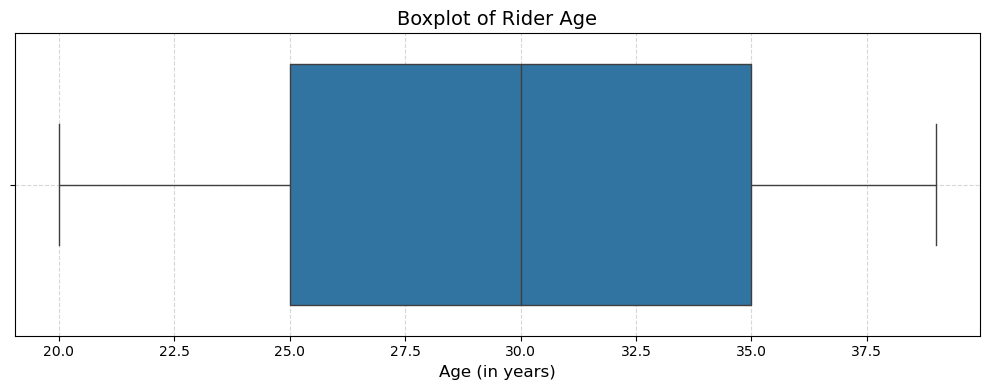

In [43]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_final['age'])
plt.title("Boxplot of Rider Age", fontsize=14)
plt.xlabel("Age (in years)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


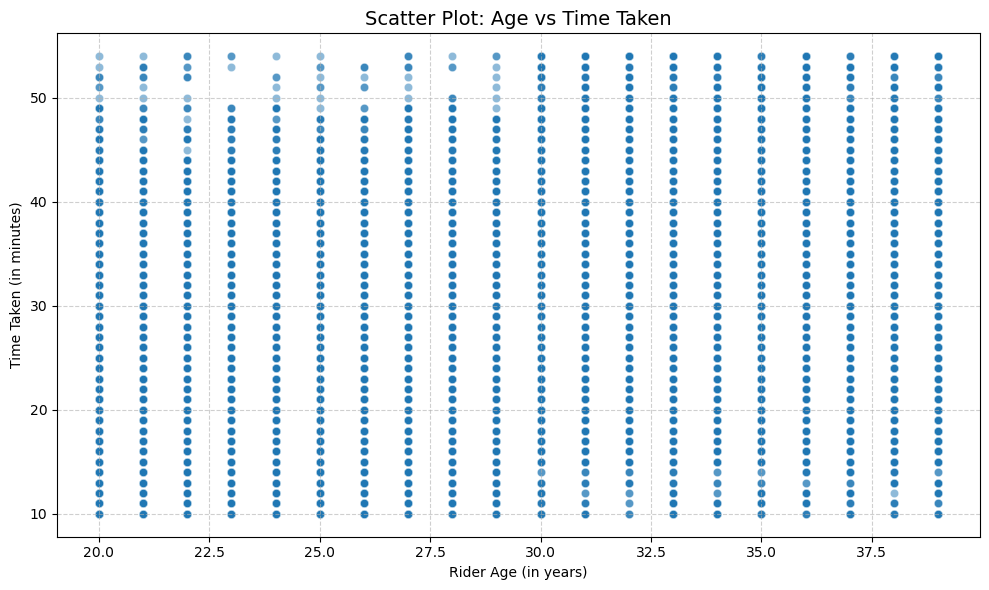

In [44]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x='age', y='time_taken', alpha=0.5)
plt.title("Scatter Plot: Age vs Time Taken", fontsize=14)
plt.xlabel("Rider Age (in years)")
plt.ylabel("Time Taken (in minutes)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


**Age of the rider does not show any impact on timetaken to deliver**

## Type_of_Vehcile

In [45]:
df_final['type_of_vehicle'].value_counts()

type_of_vehicle
motorcycle          26345
scooter             15102
electric_scooter     3626
Name: count, dtype: int64

C:\Users\vkyad\AppData\Local\Temp\ipykernel_20768\2360628754.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=data.index, y=data.values,edgecolor='black',palette='muted')


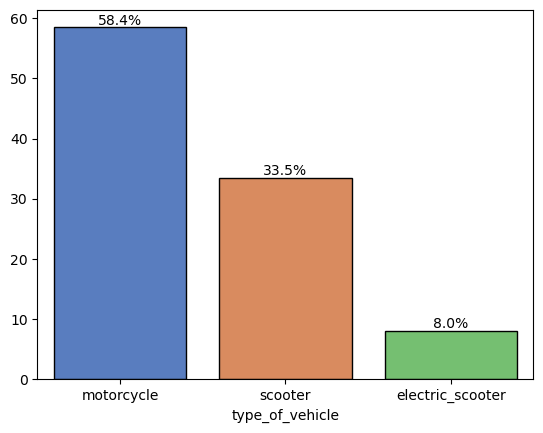

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

data = df_final['type_of_vehicle'].value_counts(normalize=True) * 100
ax = sns.barplot(x=data.index, y=data.values,edgecolor='black',palette='muted')


for bars in ax.containers:
    ax.bar_label(bars, labels=[f'{h.get_height():.1f}%' for h in bars])

plt.savefig("vehicle_type_distribution.png", dpi=300)
plt.show()



## Ratings

In [47]:
# data type of rating column

df_final['ratings'].dtype

dtype('float64')

In [48]:
# statistical summary

df_final['ratings'].describe()

count    43594.000000
mean         4.635287
std          0.313827
min          2.500000
25%          4.500000
50%          4.700000
75%          4.900000
max          5.000000
Name: ratings, dtype: float64

In [49]:

# Assuming this is a Series
rating_counts = df_final['ratings'].value_counts().sort_index()

# Convert to DataFrame
rating_df = rating_counts.reset_index()
rating_df.columns = ['rating', 'count']

# Add percentage column
rating_df['percentage'] = (rating_df['count'] / rating_df['count'].sum() * 100).round(2)

rating_df.sort_values(by = 'percentage',ascending=False)


,rating,count,percentage
23,4.8,7148,16.40
22,4.7,7142,16.38
24,4.9,7041,16.15
21,4.6,6940,15.92
25,5.0,3996,9.17
20,4.5,3303,7.58
16,4.1,1430,3.28
17,4.2,1418,3.25
18,4.3,1409,3.23
19,4.4,1361,3.12


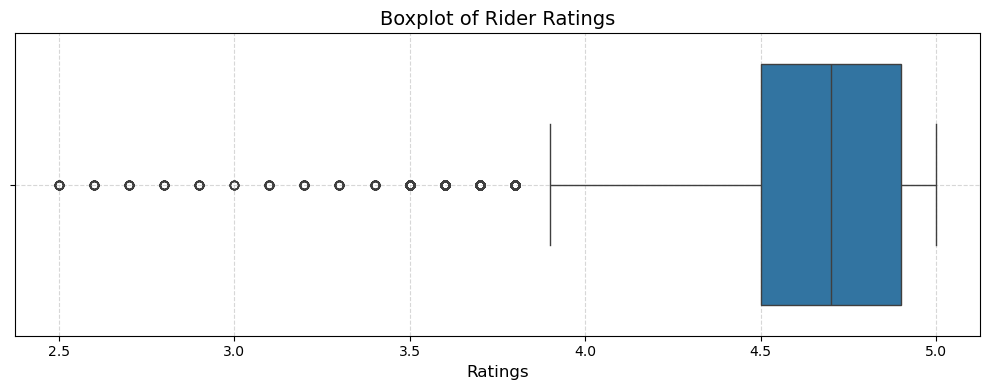

In [50]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_final['ratings'])

plt.title("Boxplot of Rider Ratings", fontsize=14)
plt.xlabel("Ratings", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


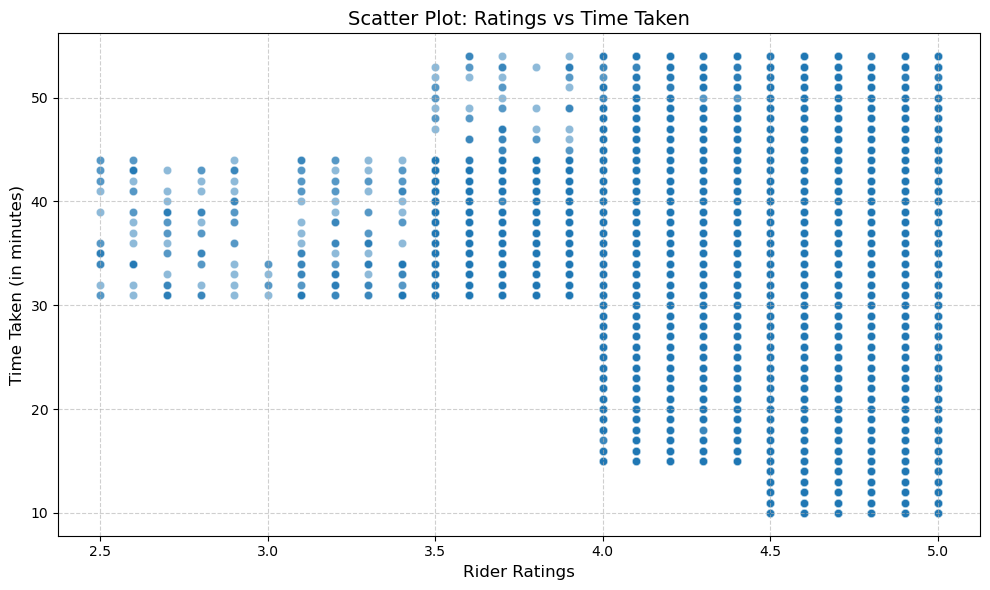

In [51]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x='ratings', y='time_taken', alpha=0.5)

# Title and Axis Labels (fixed)
plt.title("Scatter Plot: Ratings vs Time Taken", fontsize=14)
plt.xlabel("Rider Ratings", fontsize=12)
plt.ylabel("Time Taken (in minutes)", fontsize=12)

# Grid and layout
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("ratings_vs_time_taken.png", dpi=300)
plt.show()


**It seems like riders with more ratings get more orders**

**Higher ratings equates to more work and more income opportunities**

## Order Date

In [52]:
df_final.columns

Index(['age', 'ratings', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time', 'order_time_of_day',
       'distance', 'time_taken_log', 'time_taken_yeojohnson'],
      dtype='object')

In [53]:
df_final.filter(like="order").head(10)

,type_of_order,order_day,order_month,order_day_of_week,order_time_of_day
0,snack,19,3,Saturday,morning
1,snack,25,3,Friday,night
2,drinks,19,3,Saturday,morning
3,buffet,5,4,Tuesday,evening
4,snack,26,3,Saturday,afternoon
5,buffet,11,3,Friday,night
6,meal,4,3,Friday,night
7,meal,14,3,Monday,evening
8,buffet,20,3,Sunday,night
9,snack,12,2,Saturday,night


In [54]:
# order date columns

order_date_subset = df_final.loc[:,["type_of_order","order_day","order_month",
                                    "order_time_of_day","order_day_of_week","is_weekend","festival"]]

order_date_subset.head(10)

,type_of_order,order_day,order_month,order_time_of_day,order_day_of_week,is_weekend,festival
0,snack,19,3,morning,Saturday,True,no
1,snack,25,3,night,Friday,False,no
2,drinks,19,3,morning,Saturday,True,no
3,buffet,5,4,evening,Tuesday,False,no
4,snack,26,3,afternoon,Saturday,True,no
5,buffet,11,3,night,Friday,False,no
6,meal,4,3,night,Friday,False,no
7,meal,14,3,evening,Monday,False,no
8,buffet,20,3,night,Sunday,True,no
9,snack,12,2,night,Saturday,True,no


In [55]:
df_final['type_of_order'].value_counts()

type_of_order
snack     11392
meal      11321
drinks    11206
buffet    11154
Name: count, dtype: int64

order_month
3    31607
2     7174
4     6292
Name: count, dtype: int64


C:\Users\vkyad\AppData\Local\Temp\ipykernel_20768\154820677.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=month_counts.index, y=month_counts.values, palette="viridis")


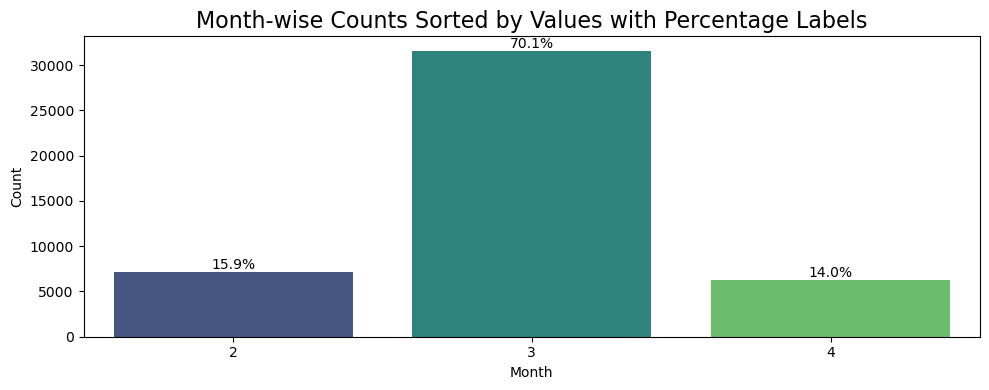

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get counts sorted by values descending
print(df_final['order_month'].value_counts())
month_counts = df_final['order_month'].value_counts()
plt.figure(figsize=(10, 4))
ax = sns.barplot(x=month_counts.index, y=month_counts.values, palette="viridis")

# Add percentage labels on top of bars using ax.containers
total = month_counts.sum()
for container in ax.containers:
    ax.bar_label(container, labels=[f'{(h.get_height()/total)*100:.1f}%' for h in container])

# Titles and labels
ax.set_title('Month-wise Counts Sorted by Values with Percentage Labels', fontsize=16)
ax.set_xlabel('Month')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()



  order_day_of_week  count
0         Wednesday   7013
1            Friday   6960
2           Tuesday   6281
3          Thursday   6279
4          Saturday   6225
5            Sunday   6177
6            Monday   6138


C:\Users\vkyad\AppData\Local\Temp\ipykernel_20768\4003934818.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=day_counts.index, y=day_counts.values, palette='muted',edgecolor='black')


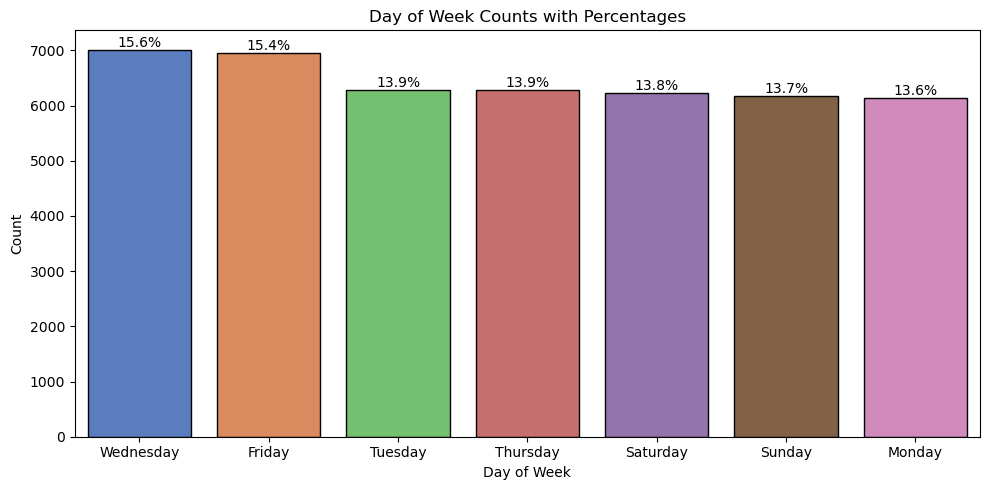

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get counts sorted descending
print(df_final['order_day_of_week'].value_counts().reset_index())
day_counts = df_final['order_day_of_week'].value_counts()

plt.figure(figsize=(10,5))
ax = sns.barplot(x=day_counts.index, y=day_counts.values, palette='muted',edgecolor='black')

total = day_counts.sum()
for container in ax.containers:
    ax.bar_label(container, labels=[f'{(h.get_height()/total)*100:.1f}%' for h in container])

ax.set_title('Day of Week Counts with Percentages')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Count')
plt.savefig("day_of_week_distribution.png", dpi=300)
plt.tight_layout()
plt.show()


order_time_of_day
night         18396
evening        8758
morning        7718
late_night     4941
afternoon      4049
Name: count, dtype: int64


C:\Users\vkyad\AppData\Local\Temp\ipykernel_20768\1059878158.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=time_of_day_counts.index, y=time_of_day_counts.values, edgecolor='black', palette='muted')


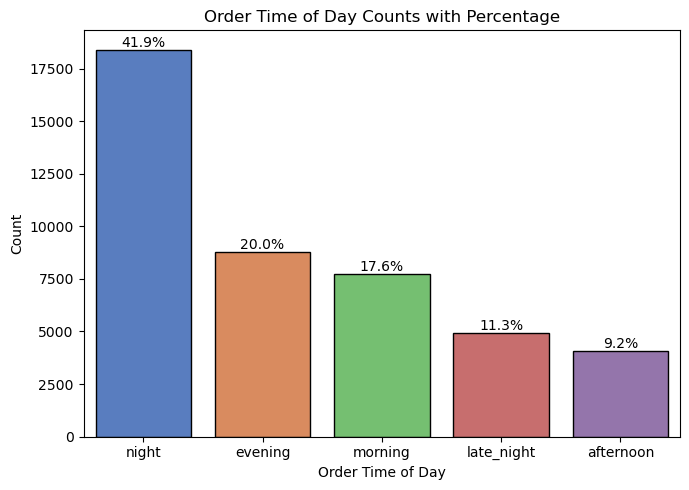

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get counts and sort descending
print(df_final['order_time_of_day'].value_counts())
time_of_day_counts = df_final['order_time_of_day'].value_counts()

plt.figure(figsize=(7, 5))
ax = sns.barplot(x=time_of_day_counts.index, y=time_of_day_counts.values, edgecolor='black', palette='muted')

total = time_of_day_counts.sum()
for container in ax.containers:
    ax.bar_label(container, labels=[f'{(h.get_height()/total)*100:.1f}%' for h in container])

ax.set_title('Order Time of Day Counts with Percentage')
ax.set_xlabel('Order Time of Day')
ax.set_ylabel('Count')
plt.savefig("order_time_distribution.png", dpi=300)
plt.tight_layout()
plt.show()


is_weekend
False    32671
True     12402
Name: count, dtype: int64


C:\Users\vkyad\AppData\Local\Temp\ipykernel_20768\3488969148.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=weekend_counts.index.astype(str), y=weekend_counts.values , edgecolor='black' , palette='muted')


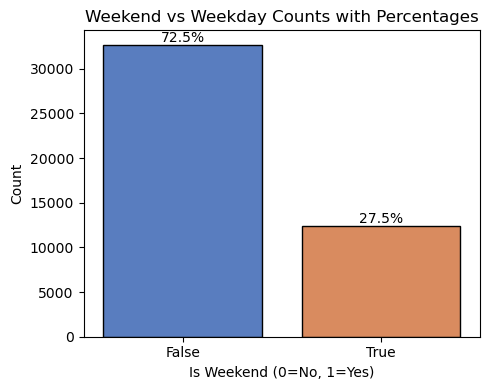

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get counts sorted descending
print(df_final['is_weekend'].value_counts())
weekend_counts = df_final['is_weekend'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(5,4))
ax = sns.barplot(x=weekend_counts.index.astype(str), y=weekend_counts.values , edgecolor='black' , palette='muted')

total = weekend_counts.sum()
for container in ax.containers:
    ax.bar_label(container, labels=[f'{(h.get_height()/total)*100:.1f}%' for h in container])

ax.set_title('Weekend vs Weekday Counts with Percentages')
ax.set_xlabel('Is Weekend (0=No, 1=Yes)')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


festival
no     43967
yes      881
Name: count, dtype: int64


C:\Users\vkyad\AppData\Local\Temp\ipykernel_20768\1233467598.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=festival_counts.index, y=festival_counts.values , edgecolor='black' , palette='muted')


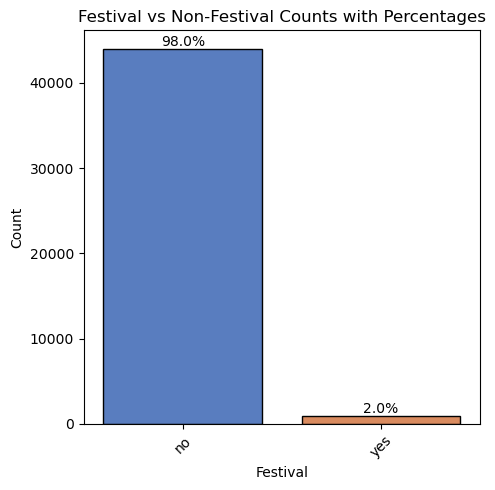

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get counts sorted descending
print(df_final['festival'].value_counts())
festival_counts = df_final['festival'].value_counts()

plt.figure(figsize=(5,5))
ax = sns.barplot(x=festival_counts.index, y=festival_counts.values , edgecolor='black' , palette='muted')

total = festival_counts.sum()
for container in ax.containers:
    ax.bar_label(container, labels=[f'{(h.get_height()/total)*100:.1f}%' for h in container])

ax.set_title('Festival vs Non-Festival Counts with Percentages')
ax.set_xlabel('Festival')
ax.set_ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


C:\Users\vkyad\AppData\Local\Temp\ipykernel_20768\1948539841.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='order_day_of_week', y='time_taken', ax=ax1,  edgecolor='black' , palette='muted' )


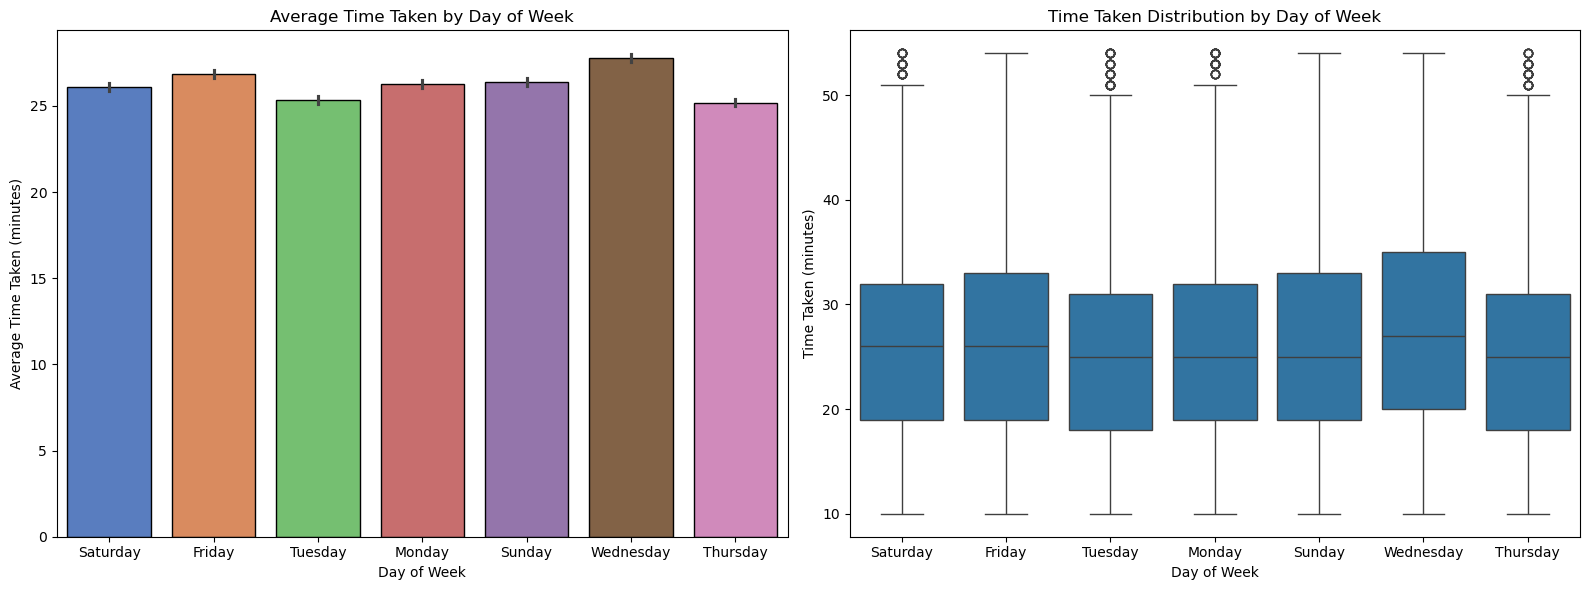

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Barplot: average time_taken per day of week
sns.barplot(data=df_final, x='order_day_of_week', y='time_taken', ax=ax1,  edgecolor='black' , palette='muted' )
ax1.set_title('Average Time Taken by Day of Week')
ax1.set_xlabel('Day of Week')
ax1.set_ylabel('Average Time Taken (minutes)')

# Boxplot: distribution of time_taken per day of week
sns.boxplot(data=df_final, x='order_day_of_week', y='time_taken', ax=ax2)
ax2.set_title('Time Taken Distribution by Day of Week')
ax2.set_xlabel('Day of Week')
ax2.set_ylabel('Time Taken (minutes)')

plt.tight_layout()
plt.show()


C:\Users\vkyad\AppData\Local\Temp\ipykernel_20768\1897762116.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='is_weekend', y='time_taken', ax=ax1,  edgecolor='black' , palette='muted')


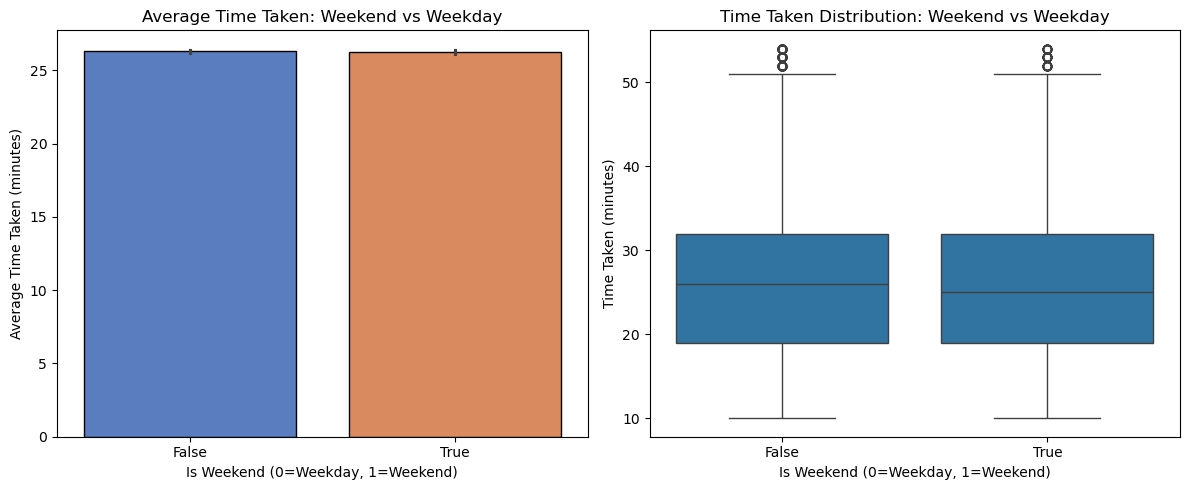

In [62]:
# does having a weekend affects target
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Barplot: average time_taken on weekend vs weekday
sns.barplot(data=df_final, x='is_weekend', y='time_taken', ax=ax1,  edgecolor='black' , palette='muted')
ax1.set_title('Average Time Taken: Weekend vs Weekday')
ax1.set_xlabel('Is Weekend (0=Weekday, 1=Weekend)')
ax1.set_ylabel('Average Time Taken (minutes)')

# Boxplot: distribution of time_taken on weekend vs weekday
sns.boxplot(data=df_final, x='is_weekend', y='time_taken', ax=ax2)
ax2.set_title('Time Taken Distribution: Weekend vs Weekday')
ax2.set_xlabel('Is Weekend (0=Weekday, 1=Weekend)')
ax2.set_ylabel('Time Taken (minutes)')

plt.tight_layout()
plt.show()


C:\Users\vkyad\AppData\Local\Temp\ipykernel_20768\1967158508.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='festival', y='time_taken', ax=ax1, edgecolor='black' , palette='muted')


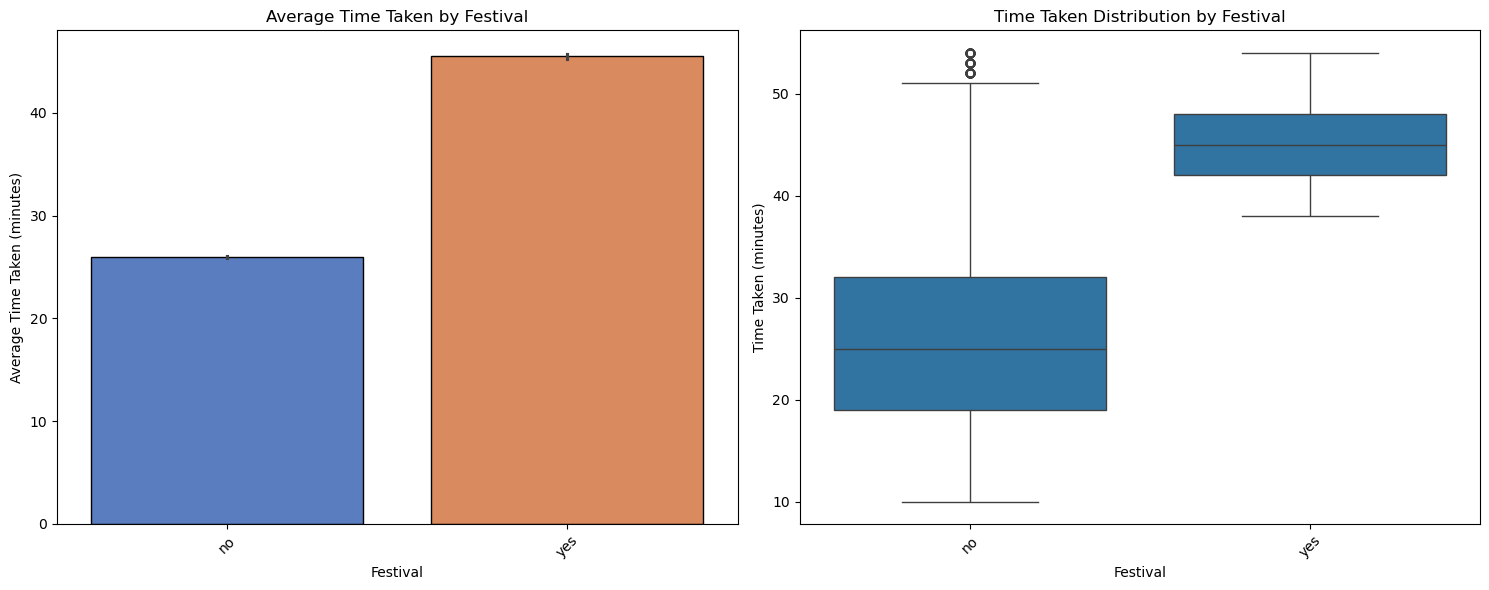

In [63]:
# festivals and target analysis

import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Barplot: average time_taken by festival
sns.barplot(data=df_final, x='festival', y='time_taken', ax=ax1, edgecolor='black' , palette='muted')
ax1.set_title('Average Time Taken by Festival')
ax1.set_xlabel('Festival')
ax1.set_ylabel('Average Time Taken (minutes)')
ax1.tick_params(axis='x', rotation=45)

# Boxplot: distribution of time_taken by festival
sns.boxplot(data=df_final, x='festival', y='time_taken', ax=ax2)
ax2.set_title('Time Taken Distribution by Festival')
ax2.set_xlabel('Festival')
ax2.set_ylabel('Time Taken (minutes)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


**Observations**:
1. The avg time it takes for delivery varies when there is a festival.
2. The range of delivery time is shorter when there is a festival with lesser variation, which means on a festival delivery times usually takes longer.

In [64]:
df_final.pivot_table(index="traffic",columns="festival",values="time_taken",aggfunc="mean")

festival,no,yes
traffic,,
high,27.010373,45.826087
jam,30.538039,46.093651
low,21.284332,42.020000
medium,26.550288,43.715385


## Pickup Time

In [65]:
# pickup_time datatype

df_final['pickup_time'].dtype

dtype('float64')

In [66]:
df_final['pickup_time'].value_counts()

pickup_time
5.0     14703
15.0    14610
10.0    14549
Name: count, dtype: int64

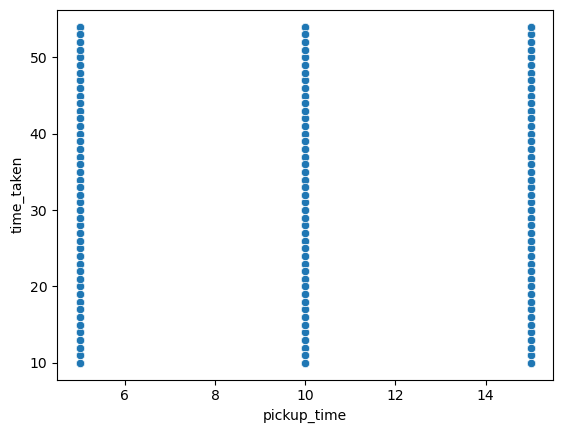

In [67]:
# relationship between pickup time and delivery time

sns.scatterplot(df_final,x="pickup_time",y="time_taken")
plt.show()

**Convert the column to ordinal categorical column**

pickup_time
5.0     14703
15.0    14610
10.0    14549
Name: count, dtype: int64


C:\Users\vkyad\AppData\Local\Temp\ipykernel_20768\3036783548.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=pickup_counts.index, y=pickup_counts.values, edgecolor='black' , palette='muted')


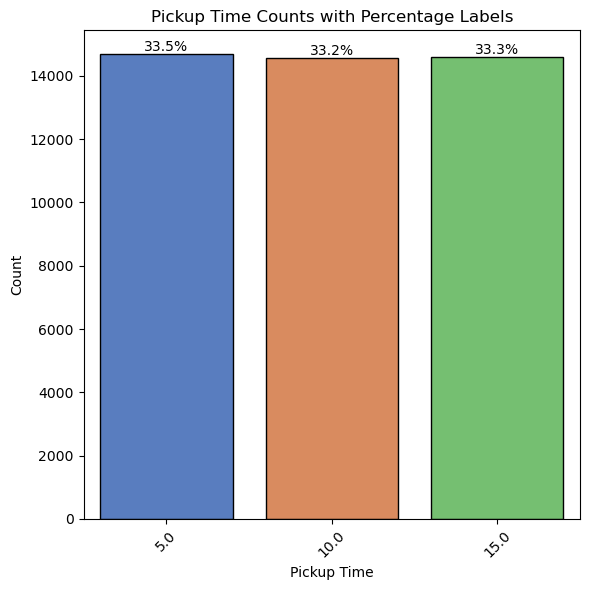

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate counts and percentages
print( df_final['pickup_time'].value_counts())
pickup_counts = df_final['pickup_time'].value_counts()


# Plot barplot
plt.figure(figsize=(6, 6))
ax = sns.barplot(x=pickup_counts.index, y=pickup_counts.values, edgecolor='black' , palette='muted')

# Add percentage labels on top of bars
for container in ax.containers:
    ax.bar_label(container, labels=[f'{(h.get_height()/pickup_counts.sum())*100:.1f}%' for h in container])

# Titles and labels
ax.set_title('Pickup Time Counts with Percentage Labels')
ax.set_xlabel('Pickup Time')
ax.set_ylabel('Count')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Traffic

In [69]:
# datatype of traffic column

df_final['traffic'].dtype

dtype('O')

traffic
low       15477
jam       14143
medium    10947
high       4425
Name: count, dtype: int64


C:\Users\vkyad\AppData\Local\Temp\ipykernel_20768\1917401691.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=traffic_counts.index, y=traffic_counts.values, edgecolor='black' , palette='muted')


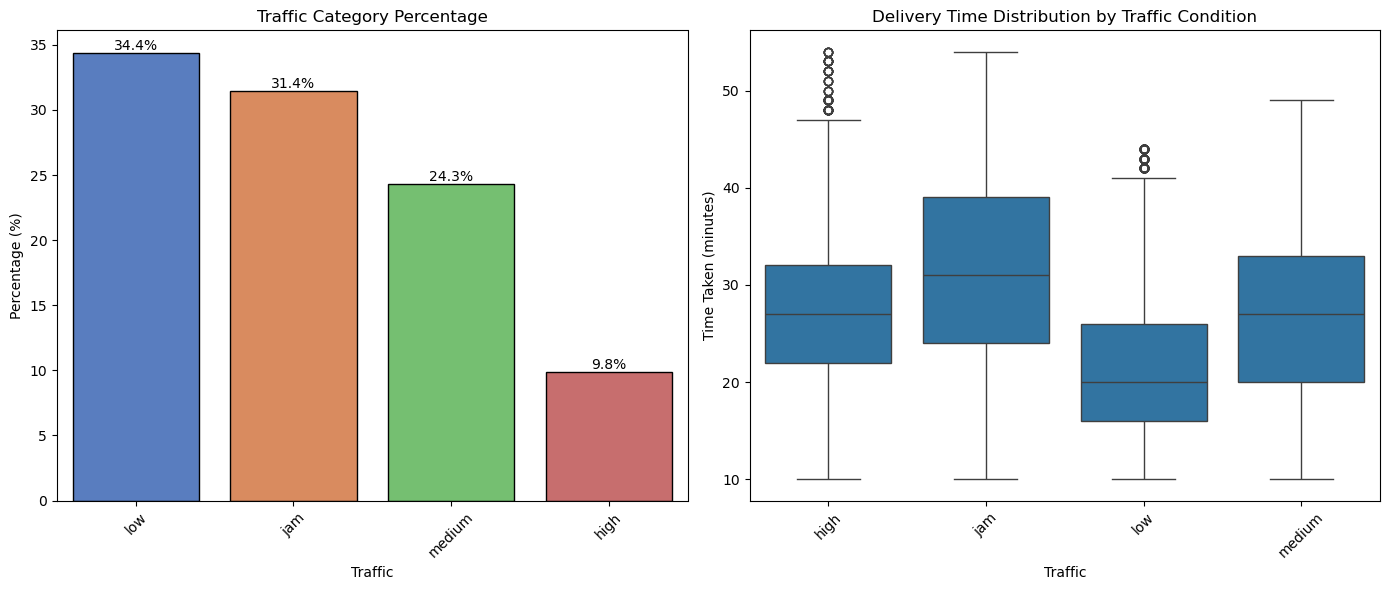

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


print(df_final['traffic'].value_counts())
plt.figure(figsize=(14, 6))

# Calculate percentage of each traffic category for barplot
traffic_counts = df_final['traffic'].value_counts(normalize=True) * 100
  # Sort by category name (optional)

# Barplot: % of each traffic category
plt.subplot(1, 2, 1)
ax = sns.barplot(x=traffic_counts.index, y=traffic_counts.values, edgecolor='black' , palette='muted')
plt.title('Traffic Category Percentage')
plt.xlabel('Traffic')
plt.ylabel('Percentage (%)')

# Add % labels on top of bars
for container in ax.containers:
    ax.bar_label(container, labels=[f'{v.get_height():.1f}%' for v in container])

plt.xticks(rotation=45)

# Boxplot: distribution of time_taken by traffic category
plt.subplot(1, 2, 2)
sns.boxplot(data=df_final, x='traffic', y='time_taken')
plt.title('Delivery Time Distribution by Traffic Condition')
plt.xlabel('Traffic')
plt.ylabel('Time Taken (minutes)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



C:\Users\vkyad\AppData\Local\Temp\ipykernel_20768\2965412216.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_final, x='traffic', y='time_taken', edgecolor='black' , palette='muted')


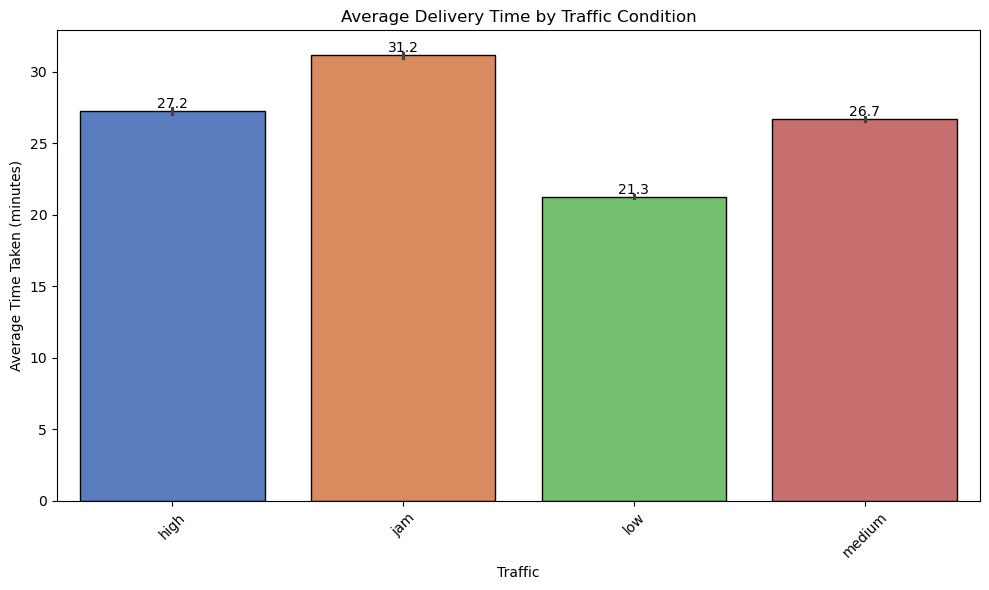

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_final, x='traffic', y='time_taken', edgecolor='black' , palette='muted')

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.title('Average Delivery Time by Traffic Condition')
plt.xlabel('Traffic')
plt.ylabel('Average Time Taken (minutes)')
plt.xticks(rotation=45)
plt.savefig("delivery_time_by_traffic.png", dpi=300)
plt.tight_layout()
plt.show()


## Multiple Deliveries

In [72]:
df_final['multiple_deliveries'].value_counts()

multiple_deliveries
1.0    27837
0.0    13937
2.0     1960
3.0      355
Name: count, dtype: int64

## Weather

In [73]:
# data type of weather column

df_final['weather'].dtype

dtype('O')

In [74]:
df_final['weather'].value_counts()

weather
fog           7654
stormy        7586
cloudy        7536
sandstorms    7495
windy         7422
sunny         7284
Name: count, dtype: int64

C:\Users\vkyad\AppData\Local\Temp\ipykernel_20768\162060285.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dataframe, x=cat_col, y=num_col, ax=axes[0], edgecolor='black' , palette='muted')


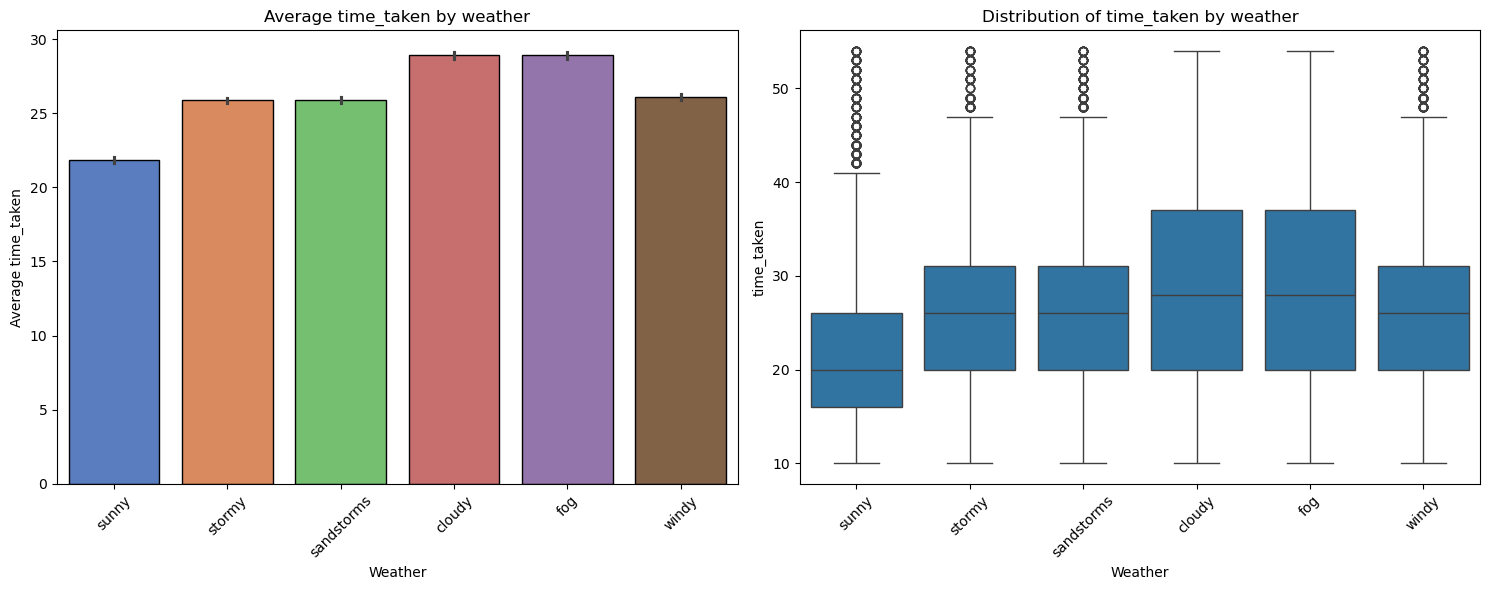

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_weather_time_taken(dataframe, cat_col='weather', num_col='time_taken'):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Bar plot: average time_taken per weather category
    sns.barplot(data=dataframe, x=cat_col, y=num_col, ax=axes[0], edgecolor='black' , palette='muted')
    axes[0].set_title(f'Average {num_col} by {cat_col}')
    axes[0].set_xlabel(cat_col.capitalize())
    axes[0].set_ylabel(f'Average {num_col}')
    axes[0].tick_params(axis='x', rotation=45)

    # Box plot: distribution of time_taken for each weather category
    sns.boxplot(data=dataframe, x=cat_col, y=num_col, ax=axes[1])
    axes[1].set_title(f'Distribution of {num_col} by {cat_col}')
    axes[1].set_xlabel(cat_col.capitalize())
    axes[1].set_ylabel(num_col)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Call the function
plot_weather_time_taken(df_final, 'weather', 'time_taken')


In [76]:
# pivot table

df_final.pivot_table(index="weather",columns="traffic",values="time_taken",aggfunc="mean")

traffic,high,jam,low,medium
weather,,,,
cloudy,28.940860,36.689655,22.208445,28.483134
fog,28.426546,36.806916,22.303427,28.044816
sandstorms,27.711840,30.018758,20.297049,27.738522
stormy,27.845839,29.850194,20.681734,27.680502
sunny,23.448980,23.082132,21.449293,20.195518
windy,26.972789,30.219056,20.665862,27.888769


## Vehicle - Condition and Type

In [77]:
# categorical analysis on vehicle condition

df_final["vehicle_condition"].value_counts()

vehicle_condition
2    15034
1    15030
0    15009
Name: count, dtype: int64

C:\Users\vkyad\AppData\Local\Temp\ipykernel_20768\30894905.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=cat_col, y=num_col, ax=axes[0], edgecolor='black' , palette='muted')


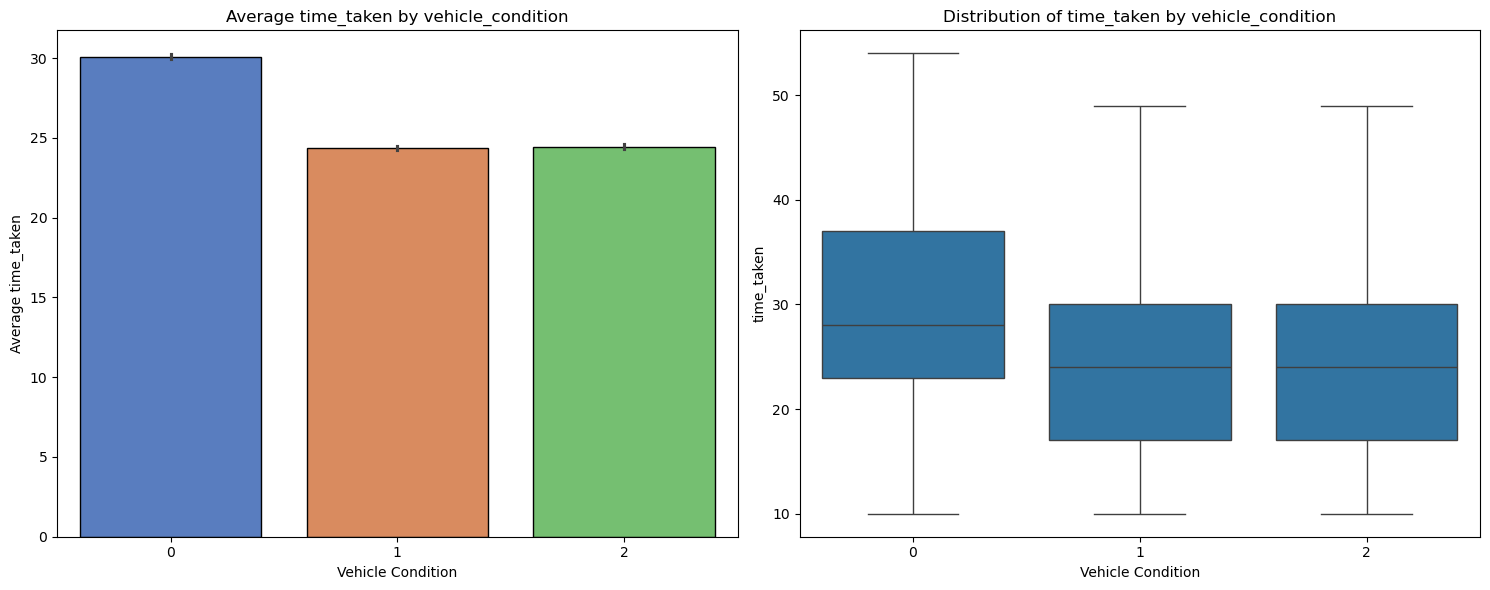

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_vehicle_condition_vs_time(df, cat_col='vehicle_condition', num_col='time_taken'):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Bar Plot
    sns.barplot(data=df, x=cat_col, y=num_col, ax=axes[0], edgecolor='black' , palette='muted')
    axes[0].set_title(f'Average {num_col} by {cat_col}')
    axes[0].set_xlabel('Vehicle Condition')
    axes[0].set_ylabel(f'Average {num_col}')

    # Box Plot
    sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[1])
    axes[1].set_title(f'Distribution of {num_col} by {cat_col}')
    axes[1].set_xlabel('Vehicle Condition')
    axes[1].set_ylabel(num_col)

    plt.tight_layout()
    plt.show()

# Call the function
plot_vehicle_condition_vs_time(df_final, "vehicle_condition", "time_taken")


## Type of Order

In [79]:
# type of order dtype

df_final['type_of_order'].dtype

dtype('O')

In [80]:
# analysis on type of order

df_final["type_of_order"].value_counts()

type_of_order
snack     11392
meal      11321
drinks    11206
buffet    11154
Name: count, dtype: int64

C:\Users\vkyad\AppData\Local\Temp\ipykernel_20768\1436439419.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=cat_col, y=num_col, ax=axes[0], edgecolor='black' , palette='muted')


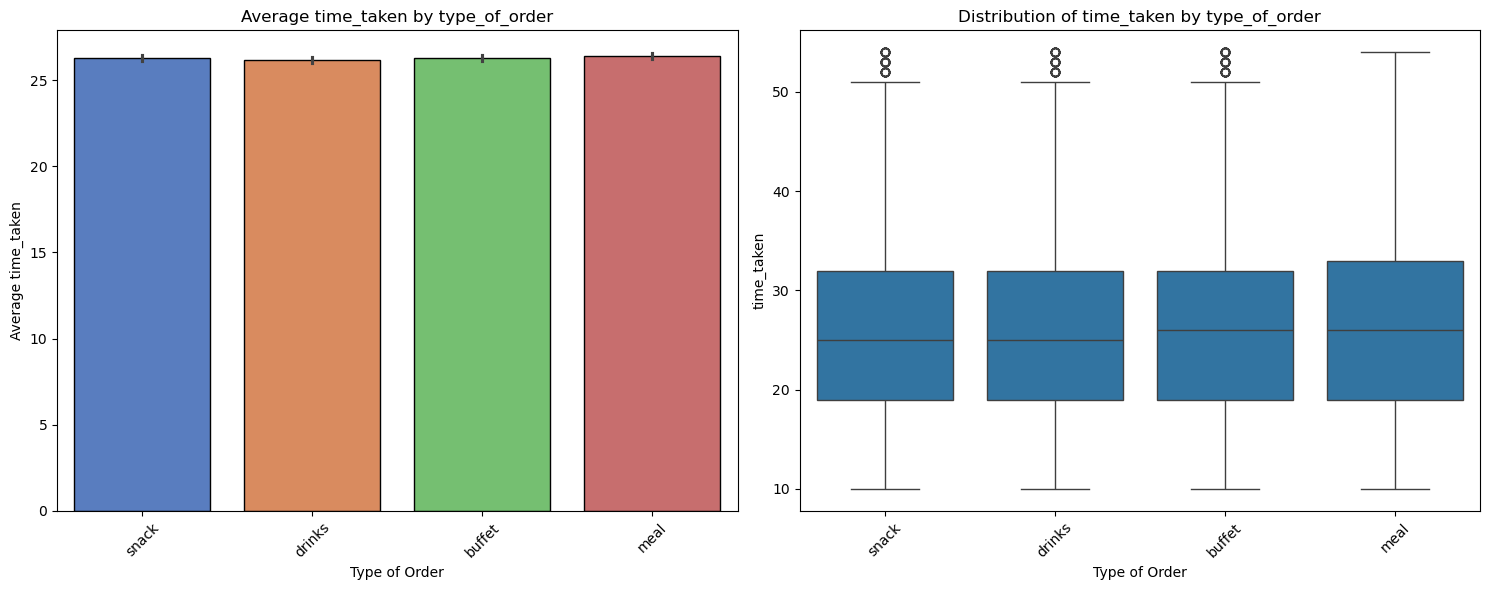

In [81]:
# does order type have have effect on delivery times
import matplotlib.pyplot as plt
import seaborn as sns

def plot_order_type_vs_time(df, cat_col='type_of_order', num_col='time_taken'):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Bar Plot: Average time taken by type of order
    sns.barplot(data=df, x=cat_col, y=num_col, ax=axes[0], edgecolor='black' , palette='muted')
    axes[0].set_title(f'Average {num_col} by {cat_col}')
    axes[0].set_xlabel('Type of Order')
    axes[0].set_ylabel(f'Average {num_col}')
    axes[0].tick_params(axis='x', rotation=45)

    # Box Plot: Distribution of time taken
    sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[1])
    axes[1].set_title(f'Distribution of {num_col} by {cat_col}')
    axes[1].set_xlabel('Type of Order')
    axes[1].set_ylabel(num_col)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Call the function
plot_order_type_vs_time(df_final, "type_of_order", "time_taken")


In [82]:
# contingency table

pd.crosstab(df_final["type_of_order"],df_final["is_weekend"])

is_weekend,False,True
type_of_order,,
buffet,8164,2990
drinks,8054,3152
meal,8204,3117
snack,8249,3143


## Distance

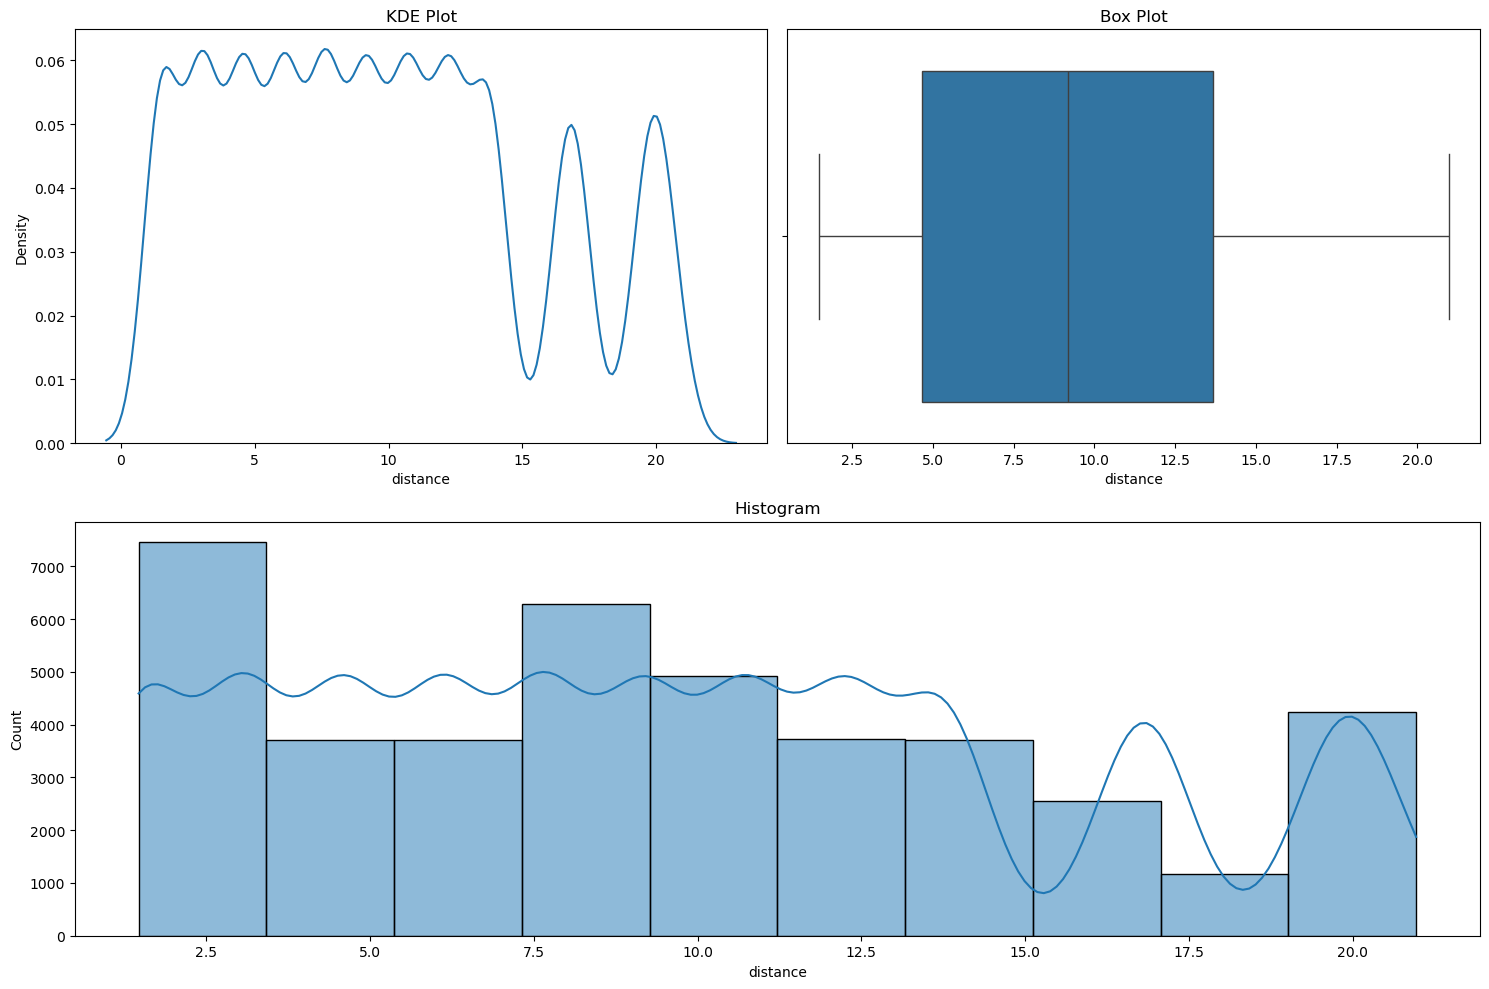

In [83]:
# numerical analysis of distance

numerical_analysis(df_final, "distance",bins=10)

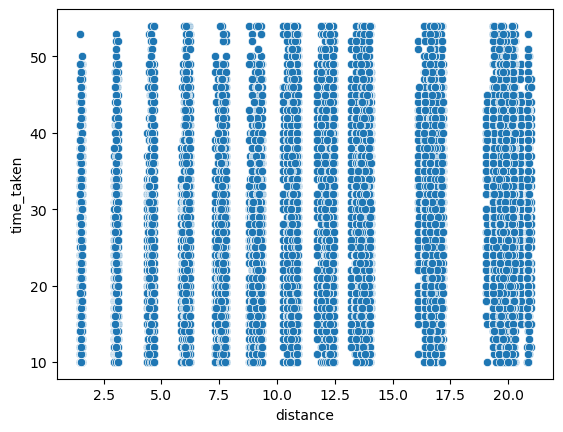

In [84]:
# relationship between distance and delivery times

sns.scatterplot(df_final,x="distance",y="time_taken")
plt.show()